<h2>Mineração de Dados aplicada a Pegada de Carbono</h2>
<h3>Aluno: Renan Avelino de Castro Andrade</h3>
<h3>Prontuário: BI3032345 || Turma: ENG241</h3>
<p>Esse projeto visa, a partir de uma base de dados que mostra comportamentos ambientais de diversos indivíduos, analisar padrões de comportamento ambiental e predizer impactos no meio ambiente com base na pegada de carbono.</p>

<h2>1. Pré-Processamento</h2>

<h4>1.1. Carregamento da base de dados e limpeza</h4>
<p>Nessa etapa será feito o carregamento da base de dados, bem como a limpeza dos mesmos para evitar problemas com dados faltantes, colunas ou linhas repetidas. Para preservar o maior número possível de registros, os valores numéricos ausentes foram substituídos pela média da variável correspondente, enquanto os valores categóricos foram preenchidos pela moda. Dessa forma, foi possível manter a representatividade da amostra sem descartar uma quantidade significativa de dados.</p>

In [2]:
import pandas as pd
import numpy as np
import plotly.express as px
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('personal_carbon_footprint_behavior.csv')

#Remoção de registros críticos
# Remove linhas que possuem mais de 3 colunas vazias para evitar dados artificiais
df.dropna(thresh=df.shape[1] - 3, inplace=True)

#Identificação dos tipos de colunas
cols_numericas = df.select_dtypes(include=[np.number]).columns
cols_categoricas = df.select_dtypes(exclude=[np.number]).columns

#Limpeza Numérica (Apenas Média)
df[cols_numericas] = df[cols_numericas].fillna(df[cols_numericas].mean())

#Limpeza Categórica (Moda)
for col in cols_categoricas:
    if not df[col].mode().empty:
        df[col] = df[col].fillna(df[col].mode()[0])

#Reseta o índice para garantir a continuidade após a remoção de linhas
df.reset_index(drop=True, inplace=True)

<h4>1.2. Transformação e Normalização</h4>
<p>Nessa etapa transformaremos todos os dados numéricos para a escala entre 0 e 1. Isso é fundamental para que atributos com valores altos <strong>(como distance_km)</strong> não dominem injustamente aqueles com escalas menores <strong>(como waste_generated_kg)</strong> durante a análise de distância.</p>

In [3]:
#Definindo os rótulos
y_kg = df['carbon_footprint_kg']
y_impact = df['carbon_impact_level']

#Preparando os dados para o t-SNE (removendo IDs e os rótulos)
X = df.drop(columns=['user_id', 'carbon_footprint_kg', 'carbon_impact_level'])

#Convertendo texto em números
X_dummies = pd.get_dummies(X)

#Aplicando Normalização Max-Min
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X_dummies)

<h4>1.3. Redução dos dados e Compressão de atributos (T-SNE)</h4>
<p>Agora reduziremos as mais de 10 variáveis originais para apenas 2 Componentes Principais, que são nossos rótulos.
<br>
<br>Antes, iremos criar uma matriz de correlação justamente para podermos "ver" como as variáveis se comportam em conjunto, e com isso poder analisar quais variáveis mais <strong>aumentam</strong> a pegada de carbono e quais mais ajudam a <strong>reduzir</strong> a pegada de carbono.
</p>

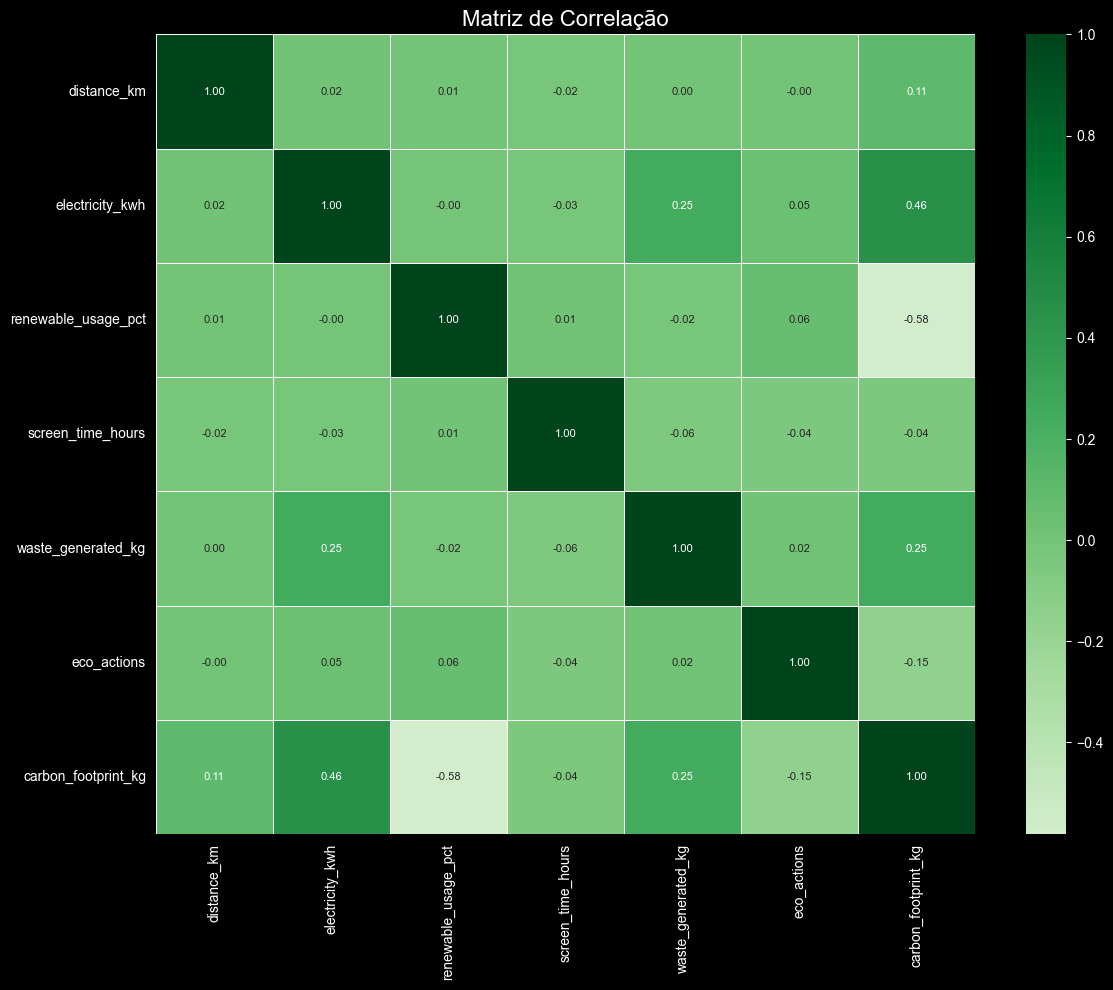

In [4]:
df_para_corr = df.drop(columns=['user_id'], errors='ignore')

#Seleção automática de colunas numéricas
df_numerico = df_para_corr.select_dtypes(include=[np.number])

#Cálculo da Matriz de Correlação
matriz_corr = df_numerico.corr()

#Configuração do Gráfico
plt.figure(figsize=(12, 10)) # Tamanho maior para caber todos os atributos

sns.heatmap(matriz_corr,
            annot=True,
            fmt=".2f",
            cmap='Greens',
            center=0,
            linewidths=0.5,
            annot_kws={"size": 8})

plt.title('Matriz de Correlação', fontsize=16)
plt.tight_layout()
plt.show()

Analisando a matriz de correlação gerada, fica evidente a correlação das demais variáveis com a Pegada de carbono.

Podemos estabelecer que as variáveis que possuem a maior correlação positiva, ou seja, que possui relação direta com a Pegada de carbono, onde quanto maior aquela variável, maior a pegada são: A eletricidade gasta (kwh) e os resíduos gerados (kg).

Por outro lado, há uma variável que se destaca por ter não só a maior correlação negativa, mas possuir a maior correlação de todas, que é o uso de energia renovável (%), que possui relação indireta com a Pegada de carbono, quanto maior a porcentagem de uso de energia renovável menor é a Pegada de carbono do indivíduo.

Iniciando busca de Perplexity ideal (KL Divergence)...
Perplexity: 5 | KL Divergence: 1.3935
Perplexity: 10 | KL Divergence: 1.6087
Perplexity: 15 | KL Divergence: 1.6816
Perplexity: 20 | KL Divergence: 1.6878
Perplexity: 25 | KL Divergence: 1.6805
Perplexity: 30 | KL Divergence: 1.6580
Perplexity: 35 | KL Divergence: 1.6450
Perplexity: 40 | KL Divergence: 1.6447
Perplexity: 45 | KL Divergence: 1.5978
Perplexity: 50 | KL Divergence: 1.5638


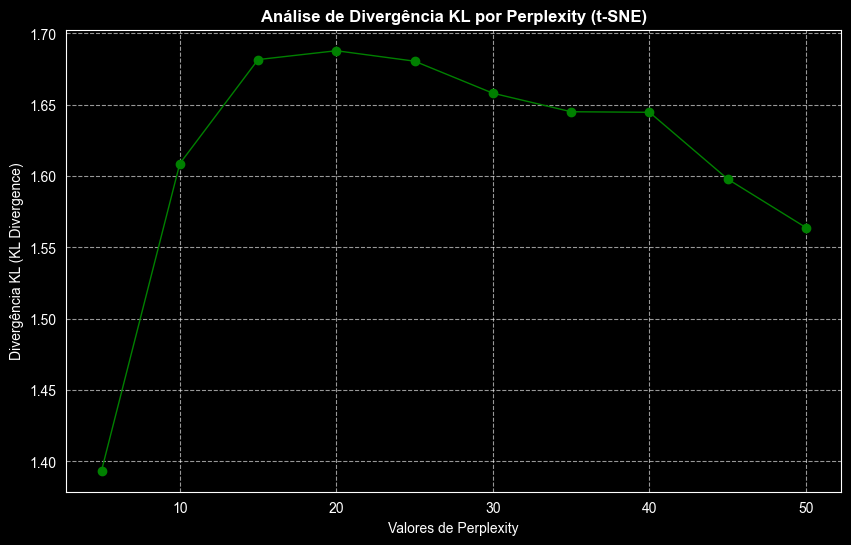


MEMORIAL TÉCNICO: OTIMIZAÇÃO DE HIPERPARÂMETROS
--------------------------------------------------
P=5  | Divergência KL: 1.3935
P=10 | Divergência KL: 1.6087
P=15 | Divergência KL: 1.6816
P=20 | Divergência KL: 1.6878
P=25 | Divergência KL: 1.6805
P=30 | Divergência KL: 1.6580
P=35 | Divergência KL: 1.6450
P=40 | Divergência KL: 1.6447
P=45 | Divergência KL: 1.5978
P=50 | Divergência KL: 1.5638


In [5]:
perplexity_values = np.arange(5, 55, 5)
divergence = []

colunas_treino = df.select_dtypes(include=[np.number]).columns.tolist()
if 'user_id' in colunas_treino:
    colunas_treino.remove('user_id')

#Criando o X (dados brutos)
X = df[colunas_treino].dropna()

#O t-SNE exige dados escalonados (média 0, variância 1)
scaler = StandardScaler()
X_train = scaler.fit_transform(X)

print("Iniciando busca de Perplexity ideal (KL Divergence)...")

#Loop para calcular a divergência para cada valor
for i in perplexity_values:
    #Usando init="pca" para maior estabilidade
    model = TSNE(n_components=2, init="pca", perplexity=i, random_state=42)
    model.fit_transform(X_train) #Dados normalizados
    divergence.append(model.kl_divergence_)
    print(f"Perplexity: {i} | KL Divergence: {model.kl_divergence_:.4f}")

#Plotagem
plt.figure(figsize=(10, 6))
plt.plot(perplexity_values, divergence, marker='o', linestyle='-', color='green', linewidth=1)

#Estilização
plt.title("Análise de Divergência KL por Perplexity (t-SNE)", fontsize=12, fontweight='bold')
plt.xlabel("Valores de Perplexity", fontsize=10)
plt.ylabel("Divergência KL (KL Divergence)", fontsize=10)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

print("\n" + "="*50)
print("MEMORIAL TÉCNICO: OTIMIZAÇÃO DE HIPERPARÂMETROS")
print("-" * 50)
for p, d in zip(perplexity_values, divergence):
    print(f"P={p:<2} | Divergência KL: {d:.4f}")
print("="*50)

Para o uso do TSN-E, foi calculado o valor da perplexidade ideal para utilizar como parâmetro do mesmo. Depois dos cálculos, foi constatado que o melhor valor para perplexidade é 40.

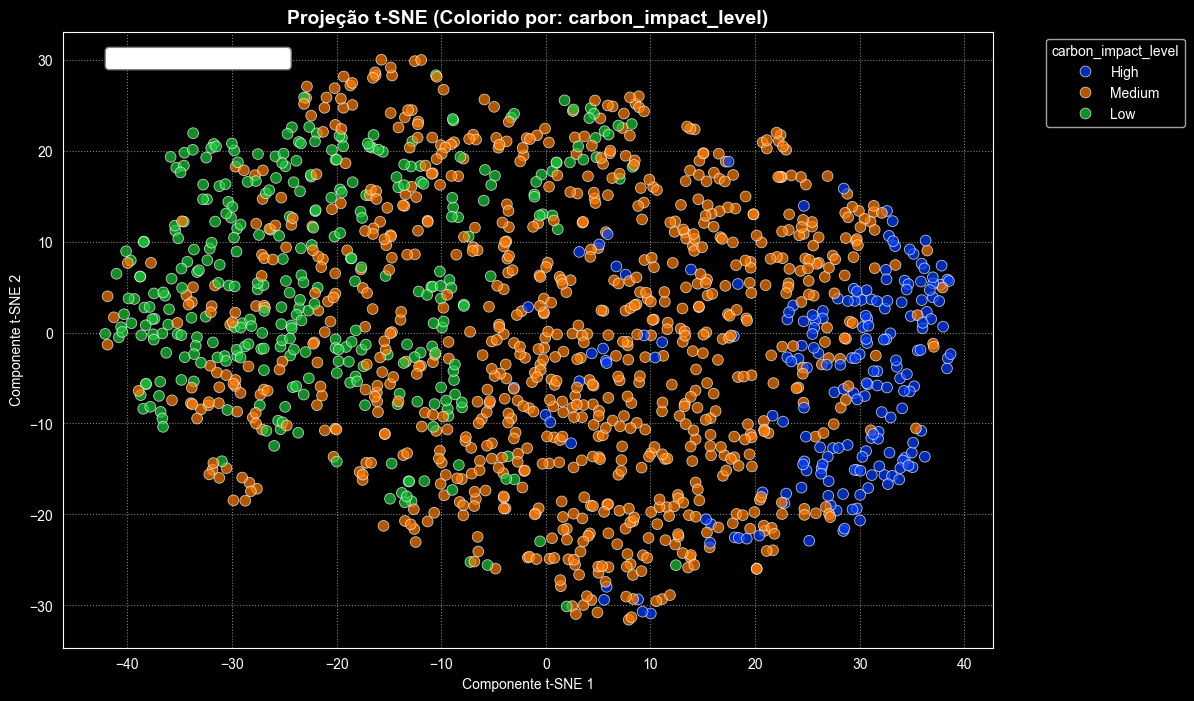

In [6]:
#Configurando o modelo (Perplexity 40 conforme a Divergencia KL)
tsne = TSNE(n_components=2,
            perplexity=40,
            init='pca',
            learning_rate='auto',
            random_state=42)

#Gerando as coordenadas 2D
X_embedded = tsne.fit_transform(X_train)

#Criando o DataFrame para o gráfico
df_tsne = pd.DataFrame(X_embedded, columns=['Dimensão 1', 'Dimensão 2'])

coluna_label = 'carbon_impact_level'

plt.figure(figsize=(12, 8))

sns.scatterplot(data=df_tsne, x='Dimensão 1', y='Dimensão 2',
                hue=df[coluna_label],
                palette='bright', s=60, alpha=0.7, edgecolor='w')

plt.title(f"Projeção t-SNE (Colorido por: {coluna_label})", fontsize=14, fontweight='bold')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title=coluna_label)
plt.xlabel("Componente t-SNE 1")
plt.ylabel("Componente t-SNE 2")
plt.grid(True, linestyle=':', alpha=0.5)

#Adicionando a Divergência KL calculada anteriormente
plt.annotate(f'Divergência KL Final: {tsne.kl_divergence_:.4f}',
             xy=(0.05, 0.95), xycoords='axes fraction',
             fontsize=10, bbox=dict(boxstyle="round", fc="white", ec="gray"))

plt.show()

O t-SNE foi utilizado para investigar visualmente possíveis agrupamentos naturais entre os indivíduos da base. A expectativa é verificar se usuários com comportamentos sustentáveis semelhantes tendem a formar grupos distintos daqueles que apresentam maior emissão de carbono. Essa visualização auxilia na compreensão da estrutura dos dados antes da aplicação dos algoritmos de agrupamento e classificação.

In [7]:
#Configurando o modelo 3D de forma simplificada
tsne_3d = TSNE(n_components=3,
               perplexity=40,
               init='pca',
               learning_rate='auto',
               random_state=42)

#Gerando as coordenadas
X_embedded_3d = tsne_3d.fit_transform(X_train)

#Criando o DataFrame para o Plotly
df_plot_3d = pd.DataFrame(X_embedded_3d, columns=['Eixo X', 'Eixo Y', 'Eixo Z'])

coluna_label = 'carbon_impact_level'
df_plot_3d[coluna_label] = df[coluna_label].values

#Gráfico Interativo
fig = px.scatter_3d(df_plot_3d,
                    x='Eixo X', y='Eixo Y', z='Eixo Z',
                    color=coluna_label,
                    title="Análise Multidimensional 3D: Impacto de Carbono",
                    labels={coluna_label: 'Nível de Impacto'},
                    color_discrete_sequence=px.colors.qualitative.Vivid,
                    opacity=0.8)

fig.update_traces(marker=dict(size=4, line=dict(width=1, color='DarkSlateGrey')))
fig.update_layout(margin=dict(l=0, r=0, b=0, t=40))

fig.show(renderer="browser")

<h2>2. Análise Descritiva</h2>

Antes da construção dos modelos de aprendizado de máquina, foi realizada uma análise estatística exploratória dos dados. Essa etapa tem como objetivo compreender o comportamento geral da população estudada, identificar tendências, verificar a dispersão dos atributos e analisar possíveis relações entre os fatores que influenciam a pegada de carbono dos indivíduos.

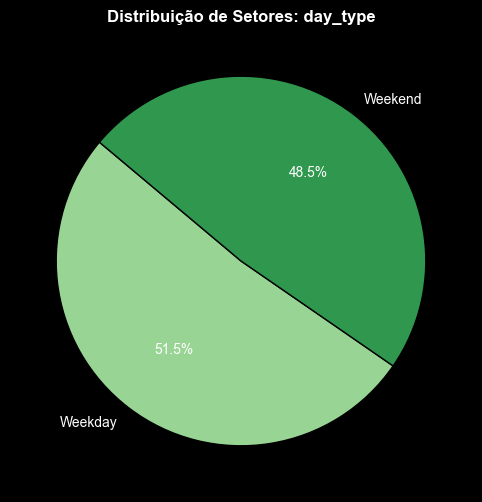


DETALHAMENTO (CATEGÓRICO): DAY_TYPE
n=1400 | Total de Categorias: 2
-------------------------------------------------------------------------------------------------------------------
No     | Categoria                 | fi    | fr %     | Fi    | Fr %    
-------------------------------------------------------------------------------------------------------------------
1      | Weekday                   | 721   |   51.50% | 721   |   51.50%
2      | Weekend                   | 679   |   48.50% | 1400  |  100.00%


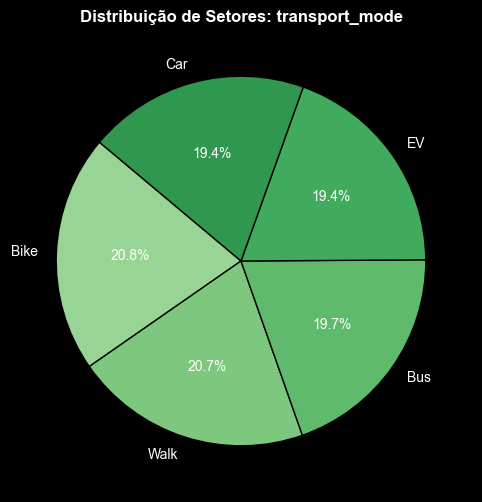


DETALHAMENTO (CATEGÓRICO): TRANSPORT_MODE
n=1400 | Total de Categorias: 5
-------------------------------------------------------------------------------------------------------------------
No     | Categoria                 | fi    | fr %     | Fi    | Fr %    
-------------------------------------------------------------------------------------------------------------------
1      | Bike                      | 291   |   20.79% | 291   |   20.79%
2      | Walk                      | 290   |   20.71% | 581   |   41.50%
3      | Bus                       | 276   |   19.71% | 857   |   61.21%
4      | EV                        | 272   |   19.43% | 1129  |   80.64%
5      | Car                       | 271   |   19.36% | 1400  |  100.00%


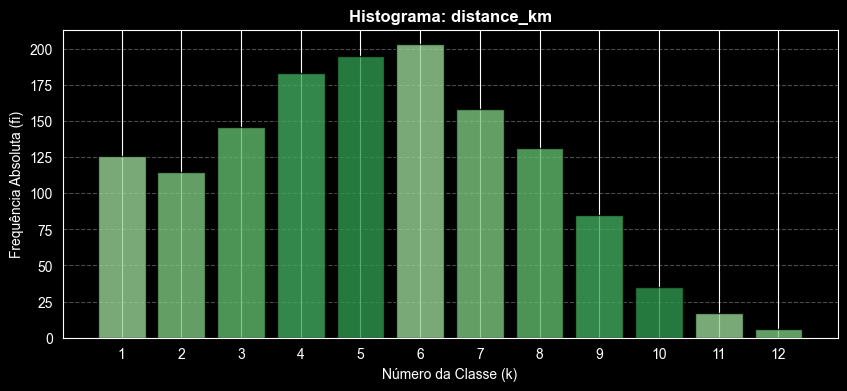


DETALHAMENTO (NUMÉRICO): DISTANCE_KM
n=1400 | k=12 | Amplitude (L)=22.17 | Largura (h)=1.85
-------------------------------------------------------------------------------------------------------------------
Classe | Intervalo [Li |--- Ls)    | xi       | fi    | fr %     | Fi    | Fr %    
-------------------------------------------------------------------------------------------------------------------
1      | [    0.50 |---     2.35)  | 1.42     | 126   |    9.00% | 126   |    9.00%
2      | [    2.35 |---     4.20)  | 3.27     | 115   |    8.21% | 241   |   17.21%
3      | [    4.20 |---     6.04)  | 5.12     | 146   |   10.43% | 387   |   27.64%
4      | [    6.04 |---     7.89)  | 6.97     | 183   |   13.07% | 570   |   40.71%
5      | [    7.89 |---     9.74)  | 8.81     | 195   |   13.93% | 765   |   54.64%
6      | [    9.74 |---    11.59)  | 10.66    | 203   |   14.50% | 968   |   69.14%
7      | [   11.59 |---    13.43)  | 12.51    | 158   |   11.29% | 1126  |   80.43%
8  

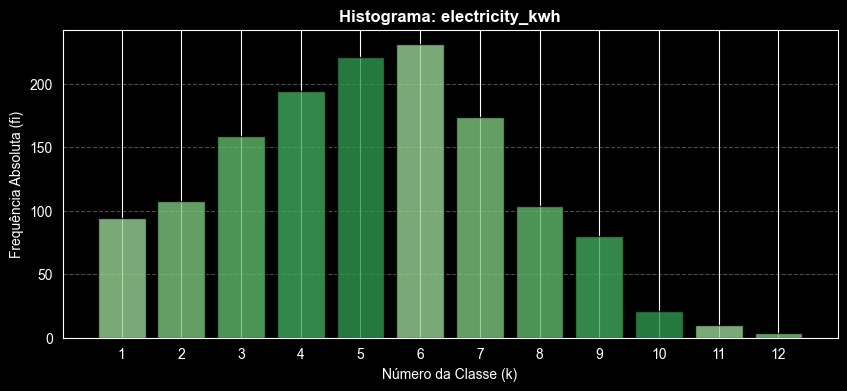


DETALHAMENTO (NUMÉRICO): ELECTRICITY_KWH
n=1400 | k=12 | Amplitude (L)=10.27 | Largura (h)=0.86
-------------------------------------------------------------------------------------------------------------------
Classe | Intervalo [Li |--- Ls)    | xi       | fi    | fr %     | Fi    | Fr %    
-------------------------------------------------------------------------------------------------------------------
1      | [    2.00 |---     2.86)  | 2.43     | 94    |    6.71% | 94    |    6.71%
2      | [    2.86 |---     3.71)  | 3.28     | 108   |    7.71% | 202   |   14.43%
3      | [    3.71 |---     4.57)  | 4.14     | 159   |   11.36% | 361   |   25.79%
4      | [    4.57 |---     5.42)  | 5.00     | 194   |   13.86% | 555   |   39.64%
5      | [    5.42 |---     6.28)  | 5.85     | 221   |   15.79% | 776   |   55.43%
6      | [    6.28 |---     7.13)  | 6.71     | 231   |   16.50% | 1007  |   71.93%
7      | [    7.13 |---     7.99)  | 7.56     | 174   |   12.43% | 1181  |   84.36%

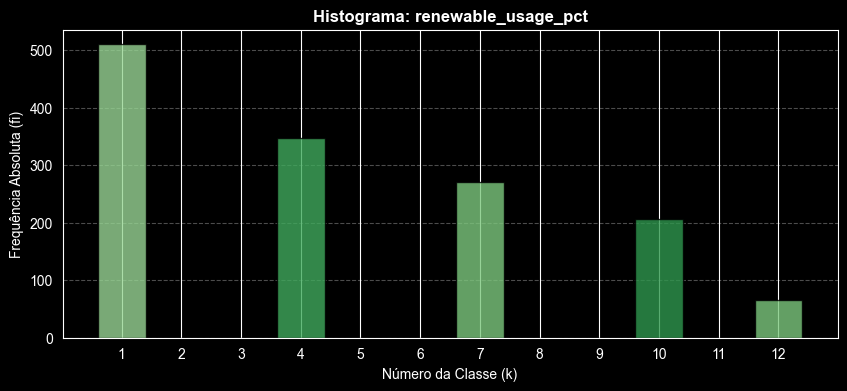


DETALHAMENTO (NUMÉRICO): RENEWABLE_USAGE_PCT
n=1400 | k=12 | Amplitude (L)=100.00 | Largura (h)=8.33
-------------------------------------------------------------------------------------------------------------------
Classe | Intervalo [Li |--- Ls)    | xi       | fi    | fr %     | Fi    | Fr %    
-------------------------------------------------------------------------------------------------------------------
1      | [    0.00 |---     8.33)  | 4.17     | 510   |   36.43% | 510   |   36.43%
2      | [    8.33 |---    16.67)  | 12.50    | 0     |    0.00% | 510   |   36.43%
3      | [   16.67 |---    25.00)  | 20.83    | 0     |    0.00% | 510   |   36.43%
4      | [   25.00 |---    33.33)  | 29.17    | 348   |   24.86% | 858   |   61.29%
5      | [   33.33 |---    41.67)  | 37.50    | 0     |    0.00% | 858   |   61.29%
6      | [   41.67 |---    50.00)  | 45.83    | 0     |    0.00% | 858   |   61.29%
7      | [   50.00 |---    58.33)  | 54.17    | 270   |   19.29% | 1128  |   8

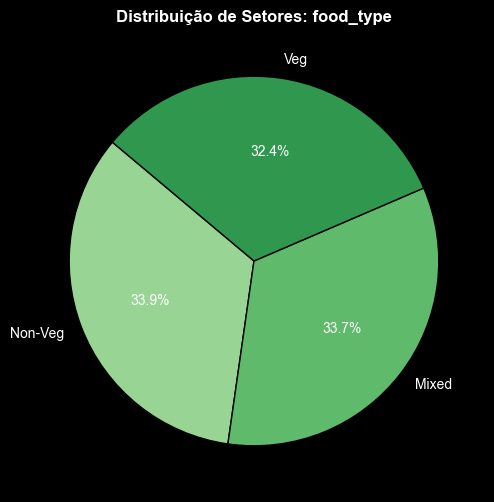


DETALHAMENTO (CATEGÓRICO): FOOD_TYPE
n=1400 | Total de Categorias: 3
-------------------------------------------------------------------------------------------------------------------
No     | Categoria                 | fi    | fr %     | Fi    | Fr %    
-------------------------------------------------------------------------------------------------------------------
1      | Non-Veg                   | 474   |   33.86% | 474   |   33.86%
2      | Mixed                     | 472   |   33.71% | 946   |   67.57%
3      | Veg                       | 454   |   32.43% | 1400  |  100.00%


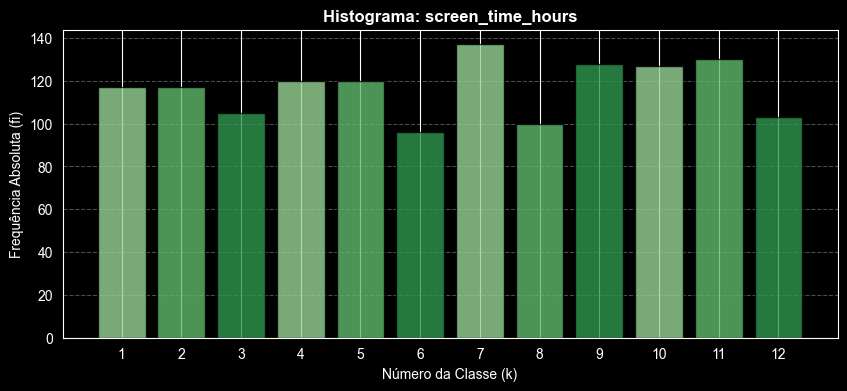


DETALHAMENTO (NUMÉRICO): SCREEN_TIME_HOURS
n=1400 | k=12 | Amplitude (L)=7.00 | Largura (h)=0.58
-------------------------------------------------------------------------------------------------------------------
Classe | Intervalo [Li |--- Ls)    | xi       | fi    | fr %     | Fi    | Fr %    
-------------------------------------------------------------------------------------------------------------------
1      | [    2.00 |---     2.58)  | 2.29     | 117   |    8.36% | 117   |    8.36%
2      | [    2.58 |---     3.17)  | 2.88     | 117   |    8.36% | 234   |   16.71%
3      | [    3.17 |---     3.75)  | 3.46     | 105   |    7.50% | 339   |   24.21%
4      | [    3.75 |---     4.33)  | 4.04     | 120   |    8.57% | 459   |   32.79%
5      | [    4.33 |---     4.92)  | 4.62     | 120   |    8.57% | 579   |   41.36%
6      | [    4.92 |---     5.50)  | 5.21     | 96    |    6.86% | 675   |   48.21%
7      | [    5.50 |---     6.08)  | 5.79     | 137   |    9.79% | 812   |   58.00

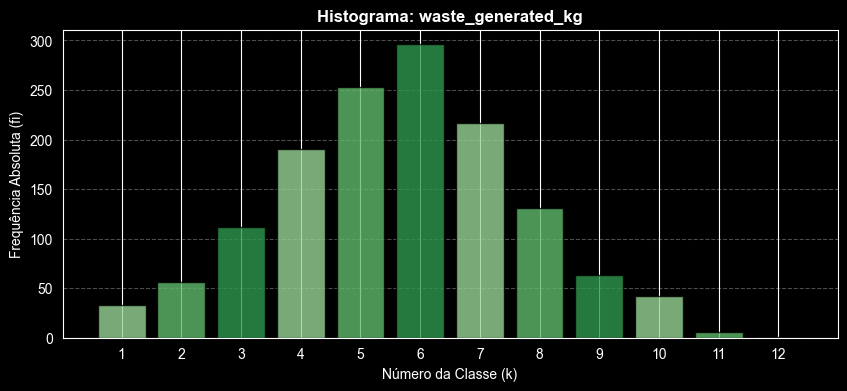


DETALHAMENTO (NUMÉRICO): WASTE_GENERATED_KG
n=1400 | k=12 | Amplitude (L)=1.41 | Largura (h)=0.12
-------------------------------------------------------------------------------------------------------------------
Classe | Intervalo [Li |--- Ls)    | xi       | fi    | fr %     | Fi    | Fr %    
-------------------------------------------------------------------------------------------------------------------
1      | [    0.10 |---     0.22)  | 0.16     | 33    |    2.36% | 33    |    2.36%
2      | [    0.22 |---     0.33)  | 0.28     | 56    |    4.00% | 89    |    6.36%
3      | [    0.33 |---     0.45)  | 0.39     | 112   |    8.00% | 201   |   14.36%
4      | [    0.45 |---     0.57)  | 0.51     | 190   |   13.57% | 391   |   27.93%
5      | [    0.57 |---     0.69)  | 0.63     | 253   |   18.07% | 644   |   46.00%
6      | [    0.69 |---     0.80)  | 0.75     | 296   |   21.14% | 940   |   67.14%
7      | [    0.80 |---     0.92)  | 0.86     | 217   |   15.50% | 1157  |   82.6

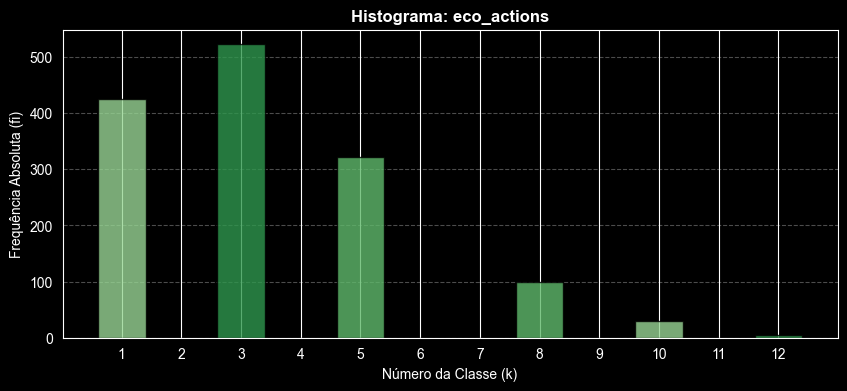


DETALHAMENTO (NUMÉRICO): ECO_ACTIONS
n=1400 | k=12 | Amplitude (L)=5.00 | Largura (h)=0.42
-------------------------------------------------------------------------------------------------------------------
Classe | Intervalo [Li |--- Ls)    | xi       | fi    | fr %     | Fi    | Fr %    
-------------------------------------------------------------------------------------------------------------------
1      | [    0.00 |---     0.42)  | 0.21     | 424   |   30.29% | 424   |   30.29%
2      | [    0.42 |---     0.83)  | 0.62     | 0     |    0.00% | 424   |   30.29%
3      | [    0.83 |---     1.25)  | 1.04     | 522   |   37.29% | 946   |   67.57%
4      | [    1.25 |---     1.67)  | 1.46     | 0     |    0.00% | 946   |   67.57%
5      | [    1.67 |---     2.08)  | 1.88     | 321   |   22.93% | 1267  |   90.50%
6      | [    2.08 |---     2.50)  | 2.29     | 0     |    0.00% | 1267  |   90.50%
7      | [    2.50 |---     2.92)  | 2.71     | 0     |    0.00% | 1267  |   90.50%
8   

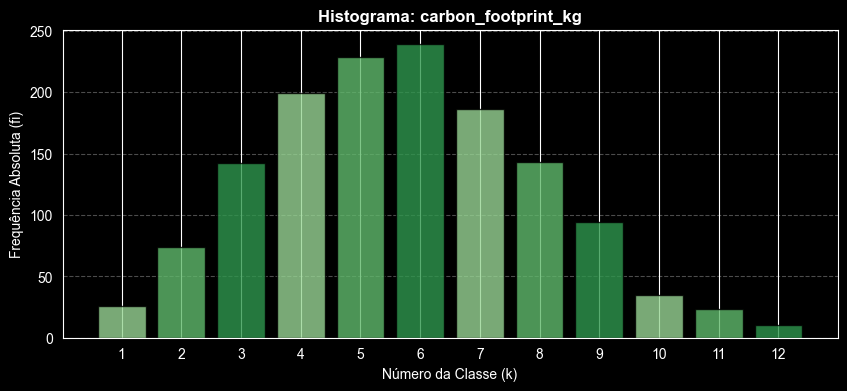


DETALHAMENTO (NUMÉRICO): CARBON_FOOTPRINT_KG
n=1400 | k=12 | Amplitude (L)=14.23 | Largura (h)=1.19
-------------------------------------------------------------------------------------------------------------------
Classe | Intervalo [Li |--- Ls)    | xi       | fi    | fr %     | Fi    | Fr %    
-------------------------------------------------------------------------------------------------------------------
1      | [    1.79 |---     2.98)  | 2.38     | 26    |    1.86% | 26    |    1.86%
2      | [    2.98 |---     4.16)  | 3.57     | 74    |    5.29% | 100   |    7.14%
3      | [    4.16 |---     5.35)  | 4.75     | 142   |   10.14% | 242   |   17.29%
4      | [    5.35 |---     6.53)  | 5.94     | 199   |   14.21% | 441   |   31.50%
5      | [    6.53 |---     7.72)  | 7.13     | 229   |   16.36% | 670   |   47.86%
6      | [    7.72 |---     8.91)  | 8.31     | 239   |   17.07% | 909   |   64.93%
7      | [    8.91 |---    10.09)  | 9.50     | 186   |   13.29% | 1095  |   78

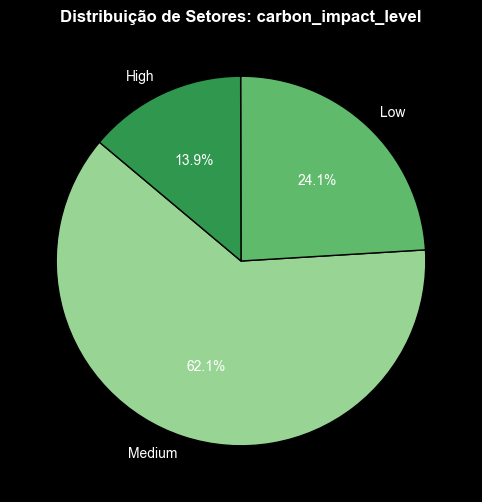


DETALHAMENTO (CATEGÓRICO): CARBON_IMPACT_LEVEL
n=1400 | Total de Categorias: 3
-------------------------------------------------------------------------------------------------------------------
No     | Categoria                 | fi    | fr %     | Fi    | Fr %    
-------------------------------------------------------------------------------------------------------------------
1      | Medium                    | 869   |   62.07% | 869   |   62.07%
2      | Low                       | 337   |   24.07% | 1206  |   86.14%
3      | High                      | 194   |   13.86% | 1400  |  100.00%


In [8]:
import math
import builtins
def analise_descritiva(dados):
    #Ignorar user_id
    colunas = [c for c in dados.columns if c != 'user_id']

    for col in colunas:
        valores_originais = dados[col].dropna()
        n = len(valores_originais)
        if n == 0: continue

        # --- PROCESSAMENTO PARA VARIÁVEIS NUMÉRICAS ---
        if pd.api.types.is_numeric_dtype(dados[col]):
            valores = valores_originais.values
            v_min, v_max = float(min(valores)), float(max(valores))
            amp = v_max - v_min
            k = math.ceil(1 + 3.322 * math.log10(n)) # Regra de Sturges
            h = amp / k if amp > 0 else 0.1

            limites = [v_min + i * h for i in range(k + 1)]
            fi_lista = []
            acumulado_fi = 0

            #Gráfico de Histograma
            plt.figure(figsize=(10, 4))
            #Cálculo de frequências para o plot
            for i in range(k):
                li, ls = limites[i], limites[i+1]
                fi = builtins.sum(1 for v in valores if (li <= v <= ls)) if i == k-1 else builtins.sum(1 for v in valores if li <= v < ls)
                fi_lista.append(fi)

            plt.bar(range(1, k+1), fi_lista, color=plt.cm.Greens(np.linspace(0.4, 0.7, len(categorias))), edgecolor='black', alpha=0.8)
            plt.title(f"Histograma: {col}", fontweight='bold')
            plt.xlabel("Número da Classe (k)")
            plt.ylabel("Frequência Absoluta (fi)")
            plt.xticks(range(1, k+1))
            plt.grid(axis='y', linestyle='--', alpha=0.3)
            plt.show()

            # Memorial Numérico
            print(f"\nDETALHAMENTO (NUMÉRICO): {col.upper()}")
            print(f"n={n} | k={k} | Amplitude (L)={amp:.2f} | Largura (h)={h:.2f}")
            print("-" * 115)
            print(f"{'Classe':<6} | {'Intervalo [Li |--- Ls)':<25} | {'xi':<8} | {'fi':<5} | {'fr %':<8} | {'Fi':<5} | {'Fr %':<8}")
            print("-" * 115)

            for i in range(k):
                li, ls = limites[i], limites[i+1]
                xi = (li + ls) / 2
                fi = fi_lista[i]
                acumulado_fi += fi
                fr = (fi / n) * 100
                fr_acum = (acumulado_fi / n) * 100
                label = f"[{li:8.2f} |--- {ls:8.2f}]" if i == k-1 else f"[{li:8.2f} |--- {ls:8.2f})"
                print(f"{i+1:<6} | {label:<25} | {xi:<8.2f} | {fi:<5} | {fr:>7.2f}% | {acumulado_fi:<5} | {fr_acum:>7.2f}%")
            print("=" * 115)

        # --- PARA VARIÁVEIS CATEGÓRICAS ---
        else:
            contagem = valores_originais.value_counts()
            categorias = contagem.index.tolist()
            fi_lista = contagem.values.tolist()

            #Gráfico de Pizza (Setores)
            plt.figure(figsize=(8, 6))
            plt.pie(fi_lista, labels=categorias, autopct='%1.1f%%', startangle=140,
                    colors=plt.cm.Greens(np.linspace(0.4, 0.7, len(categorias))), wedgeprops={'edgecolor': 'black'})
            plt.title(f"Distribuição de Setores: {col}", fontweight='bold')
            plt.show()

            #Detalhamento Categórico
            print(f"\nDETALHAMENTO (CATEGÓRICO): {col.upper()}")
            print(f"n={n} | Total de Categorias: {len(categorias)}")
            print("-" * 115)
            print(f"{'No':<6} | {'Categoria':<25} | {'fi':<5} | {'fr %':<8} | {'Fi':<5} | {'Fr %':<8}")
            print("-" * 115)
            acum_cat = 0
            for i, (cat, fi) in enumerate(zip(categorias, fi_lista)):
                fr = (fi / n) * 100
                acum_cat += fi
                fr_acum = (acum_cat / n) * 100
                print(f"{i+1:<6} | {str(cat)[:25]:<25} | {fi:<5} | {fr:>7.2f}% | {acum_cat:<5} | {fr_acum:>7.2f}%")
            print("=" * 115)

analise_descritiva(df)

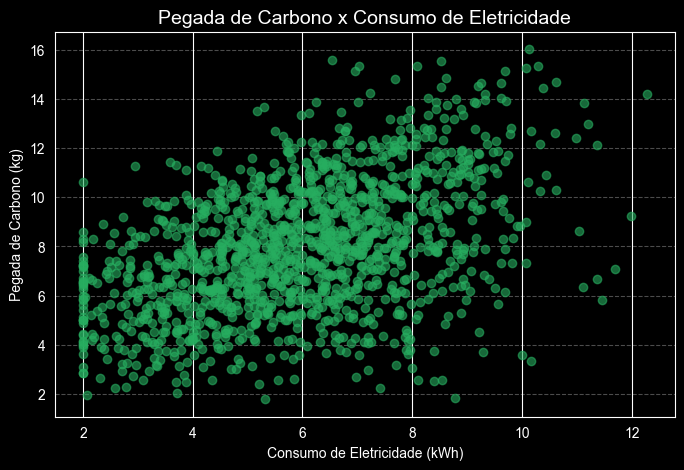

In [9]:
plt.figure(figsize=(8, 5))
plt.scatter(df['electricity_kwh'], df['carbon_footprint_kg'], alpha=0.6, color='#27ae60')
plt.title('Pegada de Carbono x Consumo de Eletricidade', fontsize=14)
plt.xlabel('Consumo de Eletricidade (kWh)')
plt.ylabel('Pegada de Carbono (kg)')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()

C:\Users\Gisele\AppData\Local\Temp\ipykernel_14844\991087337.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='intervalo_residuo', y='carbon_footprint_kg', data=df,


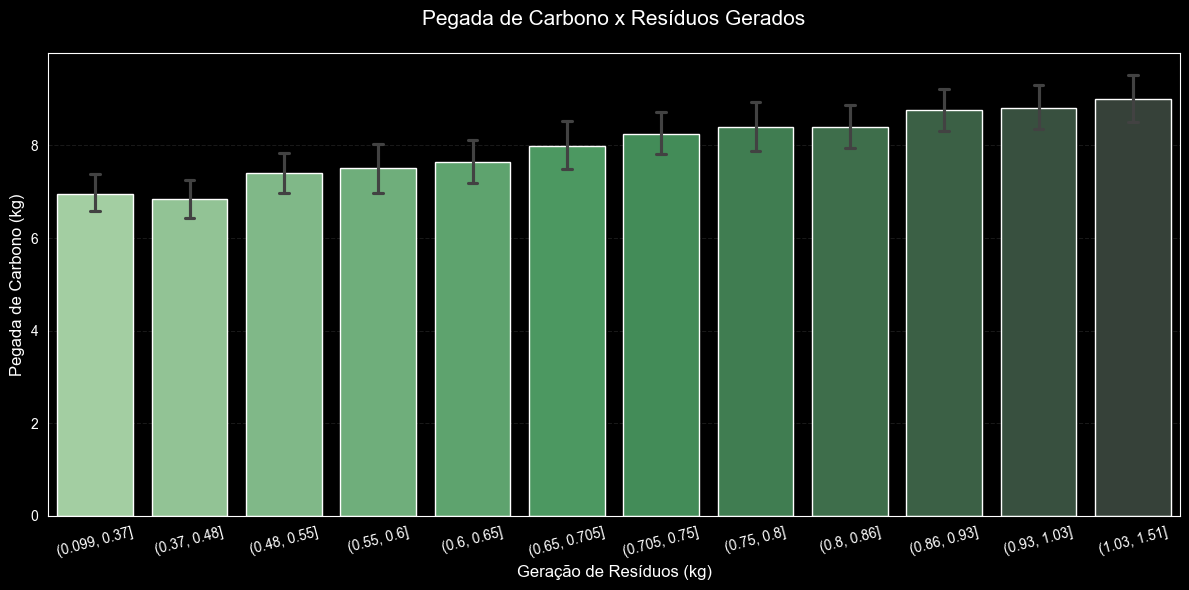

In [10]:
# 1. Criando 5 níveis de resíduos com intervalos numéricos reais
# Ao não passar 'labels', o pandas usa os intervalos (ex: (1.2, 2.5])
df['intervalo_residuo'] = pd.qcut(df['waste_generated_kg'], q=12)

# 2. Configurando o gráfico
plt.figure(figsize=(12, 6))
plt.style.use('dark_background')

# Ordenando os dados para garantir que os intervalos apareçam na ordem correta
df = df.sort_values('intervalo_residuo')

# Gerando o gráfico de barras
sns.barplot(x='intervalo_residuo', y='carbon_footprint_kg', data=df,
            palette='Greens_d', capsize=.1)

# Ajustes estéticos e de legibilidade
plt.title('Pegada de Carbono x Resíduos Gerados', fontsize=15, pad=20)
plt.xlabel('Geração de Resíduos (kg)', fontsize=12)
plt.ylabel('Pegada de Carbono (kg)', fontsize=12)

# Melhora a visualização se os números forem longos
plt.xticks(rotation=15)
plt.grid(axis='y', linestyle='--', alpha=0.1)

plt.tight_layout()
plt.show()

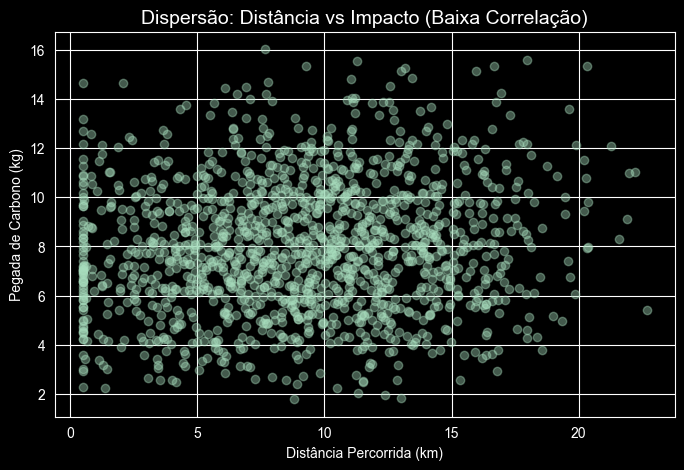

In [11]:
plt.figure(figsize=(8, 5))
plt.scatter(df['distance_km'], df['carbon_footprint_kg'], alpha=0.4, color='#a9dfbf')
plt.title('Dispersão: Distância vs Impacto (Baixa Correlação)', fontsize=14)
plt.xlabel('Distância Percorrida (km)')
plt.ylabel('Pegada de Carbono (kg)')
plt.show()

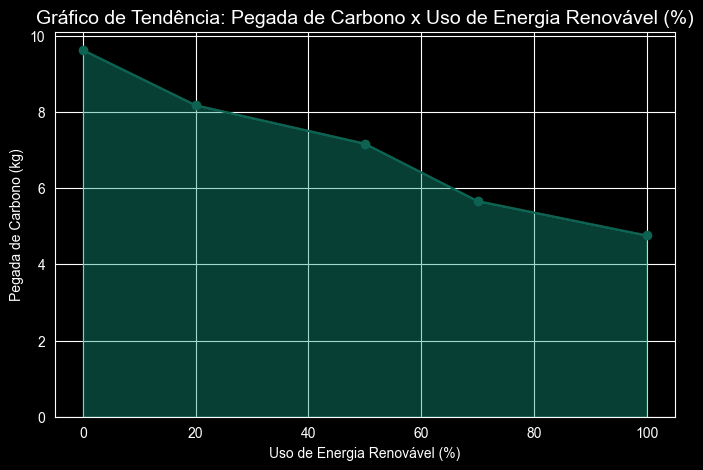

In [12]:
df['renovavel_faixa'] = (df['renewable_usage_pct'] // 10) * 10
media_renovavel = df.groupby('renovavel_faixa')['carbon_footprint_kg'].mean()

plt.figure(figsize=(8, 5))
media_renovavel.plot(kind='area', color='#16a085', alpha=0.4)
media_renovavel.plot(kind='line', color='#0e6251', marker='o')
plt.title('Gráfico de Tendência: Pegada de Carbono x Uso de Energia Renovável (%)', fontsize=14)
plt.xlabel('Uso de Energia Renovável (%)')
plt.ylabel('Pegada de Carbono (kg)')
plt.show()

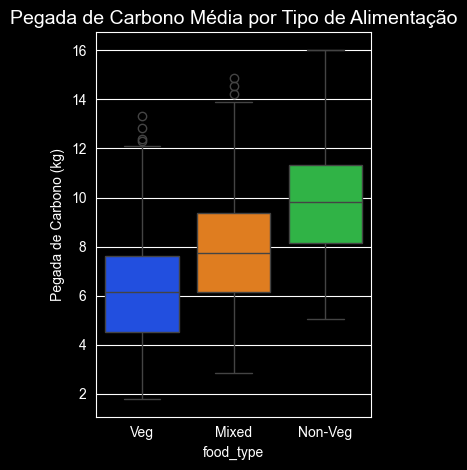

In [13]:
plt.subplot(1, 2, 2)
sns.boxplot(data=df, x='food_type', y='carbon_footprint_kg', hue='food_type', palette='bright', legend='auto')
plt.title('Pegada de Carbono Média por Tipo de Alimentação', fontsize=14)
plt.ylabel('Pegada de Carbono (kg)')

plt.tight_layout()
plt.show()

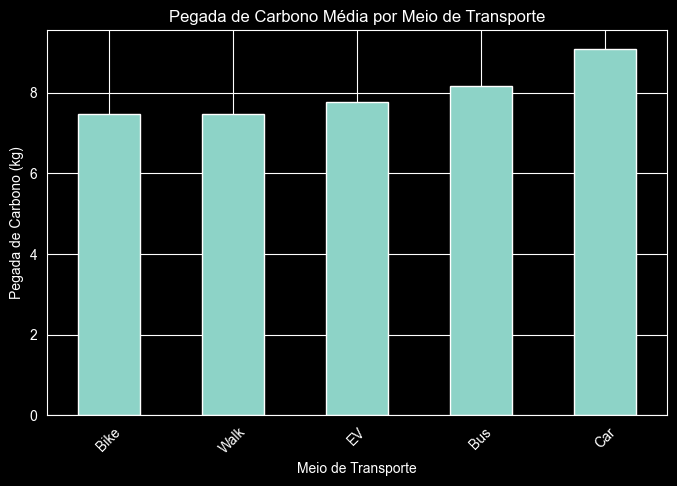

In [14]:
transport_carbon = df.groupby('transport_mode')['carbon_footprint_kg'].mean().sort_values()

plt.figure(figsize=(8,5))
transport_carbon.plot(kind='bar')
plt.title('Pegada de Carbono Média por Meio de Transporte')
plt.xlabel('Meio de Transporte')
plt.ylabel('Pegada de Carbono (kg)')
plt.xticks(rotation=45)
plt.show()

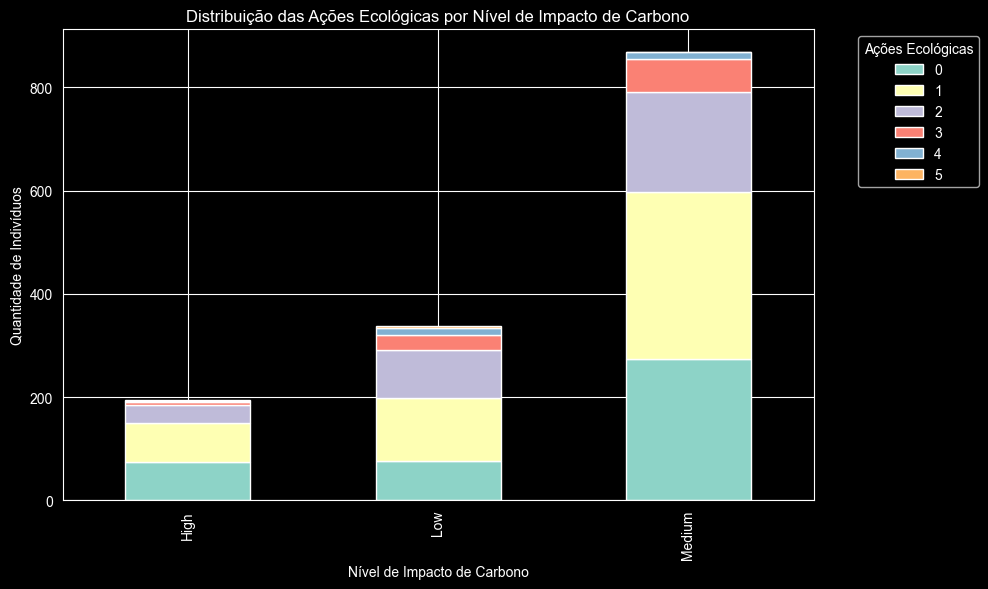

In [15]:
contagem = pd.crosstab(
    df['carbon_impact_level'],
    df['eco_actions']
)

contagem.plot(
    kind='bar',
    stacked=True,
    figsize=(10,6)
)

plt.title('Distribuição das Ações Ecológicas por Nível de Impacto de Carbono')
plt.xlabel('Nível de Impacto de Carbono')
plt.ylabel('Quantidade de Indivíduos')
plt.legend(title='Ações Ecológicas', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

<h3>Medidas de Resumo</h3>

<h4>Medidas de Tendência Central e Dispersão</h4>

<h5>Média e Mediana</h5>
O cálculo da média e da mediana permite compreender o comportamento típico dos usuários da base em relação aos indicadores de sustentabilidade. Essas medidas fornecem uma visão geral sobre o consumo médio de energia, geração de resíduos e utilização de fontes renováveis, além de auxiliar na identificação de possíveis diferenças entre indivíduos de baixo e alto impacto ambiental.

<h5>Variância e Desvio Padrão</h5>
As medidas de dispersão foram utilizadas para avaliar o grau de heterogeneidade presente na população analisada. Uma alta variabilidade em atributos como consumo de eletricidade ou emissão de carbono pode indicar a existência de perfis bastante distintos de usuários, reforçando a necessidade de técnicas de agrupamento e classificação para identificar esses padrões.

In [16]:
def calcular_media(dados):
    #Fórmula: Σx / n
    return sum(dados) / len(dados)

def calcular_mediana(dados):
    #Fórmula: Valor central do conjunto ordenado
    ordenados = sorted(dados)
    n = len(ordenados)
    meio = n // 2
    if n % 2 == 0:
        return (ordenados[meio - 1] + ordenados[meio]) / 2
    return ordenados[meio]

def calcular_ponto_medio(dados):
    #Fórmula: (Máximo + Mínimo) / 2
    return (max(dados) + min(dados)) / 2

def calcular_moda(dados):
    #Fórmula: Valor com maior frequência
    valores, contagens = np.unique(dados, return_counts=True)
    indice_max = np.argmax(contagens)
    return valores[indice_max]

def calcular_amplitude(dados):
    #Fórmula: Valor Máximo - Valor Mínimo
    return max(dados) - min(dados)

def calcular_variancia_amostral(dados):
    #Fórmula: Σ(xi - média)² / (n - 1)
    m = calcular_media(dados)
    soma_quadrados = sum((x - m) ** 2 for x in dados)
    return soma_quadrados / (len(dados) - 1)

def calcular_desvio_padrao(dados):
    #Fórmula: Raiz quadrada da Variância
    return calcular_variancia_amostral(dados) ** 0.5

def calcular_coeficiente_variacao(dados):
    #Fórmula: (Desvio Padrão / Média) * 100
    dp = calcular_desvio_padrao(dados)
    m = calcular_media(dados)
    return (dp / m) * 100

colunas_numericas = df.select_dtypes(include=[np.number]).columns

#Dicionário para armazenar os resultados de cada coluna
resumo_geral = []

for coluna in colunas_numericas:
    dados = df[coluna].values

    #Executando os cálculos para a coluna atual
    stats = {
        "Variável": coluna,
        "Média": f"{calcular_media(dados):.2f}",
        "Mediana": f"{calcular_mediana(dados):.2f}",
        "Moda": f"{calcular_moda(dados):.2f}",
        "Ponto Médio": f"{calcular_ponto_medio(dados):.2f}",
        "Amplitude": f"{calcular_amplitude(dados):.2f}",
        "Desvio Padrão": f"{calcular_desvio_padrao(dados):.2f}",
        "CV (%)": f"{calcular_coeficiente_variacao(dados):.2f}%"
    }
    resumo_geral.append(stats)

#Criando o DataFrame final
df_estatisticas = pd.DataFrame(resumo_geral)

print("--- Resumo Completo: Variáveis Numéricas ---")
print(df_estatisticas.to_string(index=False))

--- Resumo Completo: Variáveis Numéricas ---
           Variável  Média Mediana Moda Ponto Médio Amplitude Desvio Padrão  CV (%)
            user_id 100.50  100.50 1.00      100.50    199.00         57.75  57.47%
        distance_km   9.11    9.18 0.50       11.59     22.17          4.73  51.99%
    electricity_kwh   5.95    5.92 2.00        7.13     10.27          1.99  33.49%
renewable_usage_pct  31.59   25.00 0.00       50.00    100.00         30.60  96.86%
  screen_time_hours   5.52    5.55 6.70        5.50      7.00          2.02  36.56%
 waste_generated_kg   0.70    0.70 0.75        0.81      1.41          0.24  33.62%
        eco_actions   1.14    1.00 1.00        2.50      5.00          1.02  89.06%
carbon_footprint_kg   7.98    7.83 5.65        8.90     14.23          2.66  33.31%
    renovavel_faixa  29.61   20.00 0.00       50.00    100.00         29.91 101.01%


<h4>Medidas de Posição Relativa</h4>

In [17]:
def calcular_escore_z(valor, dados):
    #Fórmula: (x - média) / desvio_padrao
    m = calcular_media(dados)
    dp = calcular_desvio_padrao(dados)
    return (valor - m) / dp

def calcular_quartil(dados, q):
    #q deve ser 1 (Q1 - 25%), 2 (Q2 - 50%/Mediana) ou 3 (Q3 - 75%)
    #Fórmula baseada na posição
    ordenados = sorted(dados)
    n = len(ordenados)
    posicao = (q * (n + 1)) / 4

    #Interpolação simples para posição não inteira
    if posicao.is_integer():
        return ordenados[int(posicao) - 1]
    else:
        inferior = int(np.floor(posicao))
        superior = int(np.ceil(posicao))
        #Ajuste de índice para 0-based
        return (ordenados[inferior - 1] + ordenados[superior - 1]) / 2

def calcular_amplitude_interquartil(dados):
    #Fórmula: Q3 - Q1 (Slide 42/Boxplot)
    q1 = calcular_quartil(dados, 1)
    q3 = calcular_quartil(dados, 3)
    return q3 - q1

<h4>Medidas de Associação</h4>

In [18]:
def calcular_covariancia_amostral(dados_x, dados_y):
    #Fórmula: Σ((xi - média_x) * (yi - média_y)) / (n - 1)
    if len(dados_x) != len(dados_y):
        raise ValueError("Os conjuntos de dados devem ter o mesmo tamanho.")

    n = len(dados_x)
    media_x = calcular_media(dados_x)
    media_y = calcular_media(dados_y)

    soma_produtos = sum((dados_x[i] - media_x) * (dados_y[i] - media_y) for i in range(n))
    return soma_produtos / (n - 1)

def calcular_correlacao_pearson(dados_x, dados_y):
    #Fórmula: Covariância(x,y) / (Desvio_Padrão_x * Desvio_Padrão_y)
    cov = calcular_covariancia_amostral(dados_x, dados_y)
    dp_x = calcular_desvio_padrao(dados_x)
    dp_y = calcular_desvio_padrao(dados_y)

    return cov / (dp_x * dp_y)

<h4>Medidas de Forma</h4>

In [19]:
def calcular_assimetria(dados):
    #Fórmula: [Σ(xi - média)³ / n] / desvio_padrao³
    n = len(dados)
    m = calcular_media(dados)
    dp = calcular_desvio_padrao(dados)

    soma_cubos = sum((x - m) ** 3 for x in dados)
    return (soma_cubos / n) / (dp ** 3)

def calcular_curtose(dados):
    #Fórmula de Fisher (Excesso de Curtose):
    #[(Σ(xi - média)⁴ / n) / desvio_padrao⁴] - 3
    n = len(dados)
    m = calcular_media(dados)
    dp = calcular_desvio_padrao(dados)

    soma_quartas = sum((x - m) ** 4 for x in dados)
    #Subtraímos 3 para que a Distribuição Normal tenha Curtose = 0
    return ((soma_quartas / n) / (dp ** 4)) - 3

carbono = df['carbon_footprint_kg'].values

#Executando os cálculos de forma
valor_assimetria = calcular_assimetria(carbono)
valor_curtose = calcular_curtose(carbono)

carbono = df['carbon_footprint_kg'].values
distancia = df['distance_km'].values

#--- GERAÇÃO DAS TABELAS ---

#Tabela 1: Tendência Central
df_central = pd.DataFrame({
    "Medida": ["Média", "Mediana", "Moda", "Ponto Médio"],
    "Valor": [calcular_media(carbono), calcular_mediana(carbono),
              calcular_moda(carbono), calcular_ponto_medio(carbono)]
})

#Tabela 2: Dispersão
df_dispersao = pd.DataFrame({
    "Medida": ["Amplitude", "Variância", "Desvio Padrão", "CV (%)"],
    "Valor": [calcular_amplitude(carbono), calcular_variancia_amostral(carbono),
              calcular_desvio_padrao(carbono), calcular_coeficiente_variacao(carbono)]
})

#Tabela 3: Posição Relativa
df_posicao = pd.DataFrame({
    "Medida": ["Quartil 1 (Q1)", "Quartil 2 (Q2)", "Quartil 3 (Q3)", "Escore-Z (Amostra 1)"],
    "Valor": [calcular_quartil(carbono, 1), calcular_quartil(carbono, 2),
              calcular_quartil(carbono, 3), calcular_escore_z(carbono[0], carbono)]
})

#Tabela 4: Associação
df_associacao = pd.DataFrame({
    "Medida": ["Covariância (Dist x Carb)", "Correlação Pearson (r)"],
    "Valor": [calcular_covariancia_amostral(distancia, carbono),
              calcular_correlacao_pearson(distancia, carbono)]
})

#Tabela 5: Forma
df_forma = pd.DataFrame({
    "Medida": ["Assimetria (Skewness)", "Curtose (Kurtosis)"],
    "Valor": [calcular_assimetria(carbono), calcular_curtose(carbono)]
})

# --- EXIBIÇÃO ---
print("\n--- MEDIDAS DE TENDÊNCIA CENTRAL ---")
print(df_central.to_string(index=False))

print("\n--- MEDIDAS DE DISPERSÃO ---")
print(df_dispersao.to_string(index=False))

print("\n--- MEDIDAS DE POSIÇÃO RELATIVA ---")
print(df_posicao.to_string(index=False))

print("\n--- MEDIDAS DE ASSOCIAÇÃO ---")
print(df_associacao.to_string(index=False))

print("\n--- MEDIDAS DE FORMA ---")
print(df_forma.to_string(index=False))


--- MEDIDAS DE TENDÊNCIA CENTRAL ---
     Medida    Valor
      Média 7.980236
    Mediana 7.835000
       Moda 5.650000
Ponto Médio 8.905000

--- MEDIDAS DE DISPERSÃO ---
       Medida     Valor
    Amplitude 14.230000
    Variância  7.064207
Desvio Padrão  2.657858
       CV (%) 33.305502

--- MEDIDAS DE POSIÇÃO RELATIVA ---
              Medida     Valor
      Quartil 1 (Q1)  6.080000
      Quartil 2 (Q2)  7.835000
      Quartil 3 (Q3)  9.830000
Escore-Z (Amostra 1) -1.546447

--- MEDIDAS DE ASSOCIAÇÃO ---
                   Medida    Valor
Covariância (Dist x Carb) 1.396422
   Correlação Pearson (r) 0.110967

--- MEDIDAS DE FORMA ---
               Medida     Valor
Assimetria (Skewness)  0.233741
   Curtose (Kurtosis) -0.322972


<h2>3. Agrupamento (Clustering)</h2>
Após a compreensão inicial dos dados, foram aplicadas técnicas de agrupamento com o objetivo de identificar perfis de usuários com características semelhantes. Diferentemente da classificação supervisionada, essa abordagem não utiliza os rótulos de impacto ambiental, permitindo descobrir padrões que surgem naturalmente a partir dos hábitos de consumo e sustentabilidade registrados na base.

<h3>3.1. K-Means</h3>
O algoritmo K-Means foi empregado para separar os indivíduos em grupos com características semelhantes relacionadas ao consumo energético, geração de resíduos e emissão de carbono. A análise desses agrupamentos permite verificar se existem perfis bem definidos de usuários sustentáveis, intermediários e altamente impactantes, fornecendo uma visão complementar à classificação supervisionada.

In [20]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

#Seleção de variáveis para o agrupamento
colunas_cluster = ['electricity_kwh', 'waste_generated_kg', 'renewable_usage_pct']
dados_cluster = df[colunas_cluster]

#Normalização
scaler = StandardScaler()
dados_scaled = scaler.fit_transform(dados_cluster)

#Execução do K-means
kmeans = KMeans(n_clusters=3, n_init=10, random_state=42)
df['cluster_resultado'] = kmeans.fit_predict(dados_scaled)

#Analisando as médias de cada cluster para entender quem é quem
resumo_clusters = df.groupby('cluster_resultado')[colunas_cluster].mean()
print("--- Perfil Médio de cada Cluster ---")
print(resumo_clusters)

--- Perfil Médio de cada Cluster ---
                   electricity_kwh  waste_generated_kg  renewable_usage_pct
cluster_resultado                                                          
0                         6.024296            0.711281            70.791457
1                         7.314877            0.877551            14.197531
2                         4.611085            0.532752            17.732558


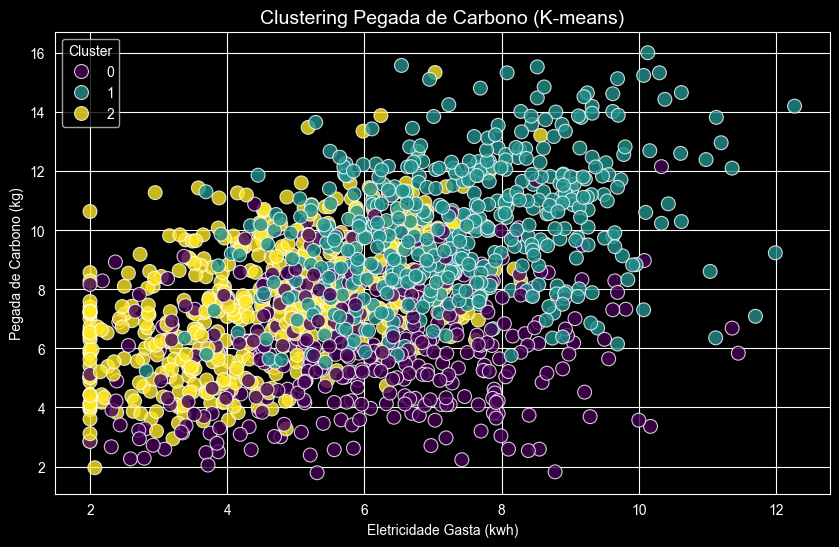

In [21]:
plt.figure(figsize=(10, 6))
plt.style.use('dark_background')

#Uso de Renováveis vs Pegada de Carbono
sns.scatterplot(data=df, x='electricity_kwh', y='carbon_footprint_kg',
                hue='cluster_resultado', palette='viridis', s=100, alpha=0.8)

plt.title('Clustering Pegada de Carbono (K-means)', fontsize=14)
plt.xlabel('Eletricidade Gasta (kwh)')
plt.ylabel('Pegada de Carbono (kg)')
plt.legend(title='Cluster')
plt.show()

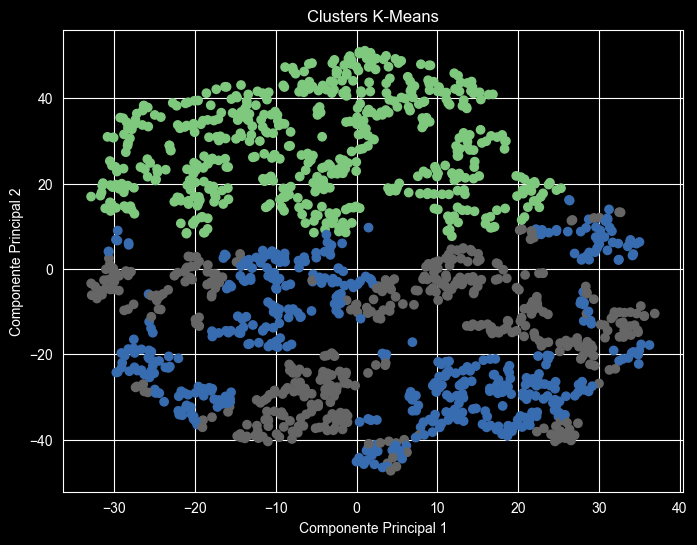

In [54]:
features_cluster = [
    'electricity_kwh',
    'waste_generated_kg',
    'renewable_usage_pct',
    'distance_km'
]

X_cluster = df[features_cluster]

scaler = MinMaxScaler()
X_cluster_scaled = scaler.fit_transform(X_cluster)

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

clusters_kmeans = kmeans.fit_predict(X_cluster_scaled)

tsne = TSNE(
    n_components=2,
    random_state=42,
    perplexity=30
)

X_tsne = tsne.fit_transform(X_scaled)

plt.figure(figsize=(8,6))

plt.scatter(
    X_tsne[:,0],
    X_tsne[:,1],
    c=clusters_kmeans,
    cmap='Accent'
)
plt.title('Clusters K-Means')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')

plt.show()

<h3>3.2. GMM (Gaussian Mixture Model)</h3>
O GMM foi utilizado como uma alternativa ao K-Means para modelar grupos potencialmente mais complexos. Como o comportamento ambiental dos indivíduos nem sempre apresenta fronteiras bem definidas, a abordagem probabilística do GMM possibilita representar situações em que um usuário pode compartilhar características de diferentes perfis de sustentabilidade.

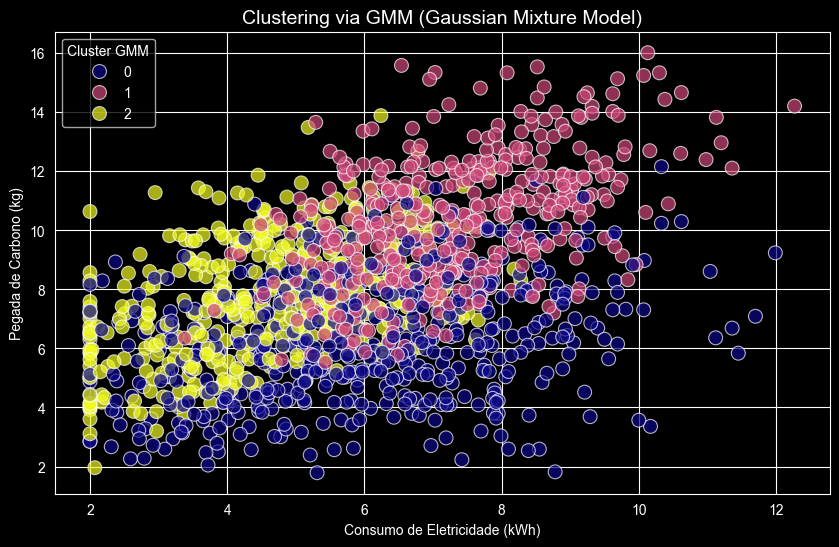

In [23]:
from sklearn.mixture import GaussianMixture

dados_scaled = scaler.fit_transform(df[colunas_cluster])

#Execução do GMM
#n_components=3 para manter a comparação com os níveis de impacto
gmm = GaussianMixture(n_components=3, random_state=42)
df['cluster_gmm'] = gmm.fit_predict(dados_scaled)

#Cálculo das Probabilidades (O diferencial do GMM)
probs = gmm.predict_proba(dados_scaled)
df['probabilidade_cluster'] = probs.max(axis=1)

#Visualização
plt.figure(figsize=(10, 6))
plt.style.use('dark_background')

sns.scatterplot(data=df, x='electricity_kwh', y='carbon_footprint_kg',
                hue='cluster_gmm', palette='plasma', s=100, alpha=0.7)

plt.title('Clustering via GMM (Gaussian Mixture Model)', fontsize=14)
plt.xlabel('Consumo de Eletricidade (kWh)')
plt.ylabel('Pegada de Carbono (kg)')
plt.legend(title='Cluster GMM')
plt.show()

In [24]:
colunas_cluster = ['electricity_kwh', 'carbon_footprint_kg', 'renewable_usage_pct']
dados_scaled = scaler.fit_transform(df[colunas_cluster])

#Execução do GMM
gmm = GaussianMixture(n_components=3, random_state=42)
df['cluster_gmm'] = gmm.fit_predict(dados_scaled)

#Converte o cluster para string para o Plotly tratá-lo como categoria discreta
df['cluster_gmm'] = df['cluster_gmm'].astype(str)

#Cálculo das Probabilidades
probs = gmm.predict_proba(dados_scaled)
df['probabilidade_cluster'] = probs.max(axis=1)

#Versão 3D Interativa
fig = px.scatter_3d(
    df,
    x='electricity_kwh',
    y='carbon_footprint_kg',
    z='renewable_usage_pct',
    color='cluster_gmm',
    color_discrete_map={'0': '#0d0887', '1': '#cc4678', '2': '#f0f921'},
    category_orders={'cluster_gmm': ['0', '1', '2']},
    title='Clustering via GMM (Gaussian Mixture Model) - Versão 3D',
    labels={
        'electricity_kwh': 'Consumo de Eletricidade (kWh)',
        'carbon_footprint_kg': 'Pegada de Carbono (kg)',
        'renewable_usage_pct': 'Uso de Energia Renovável (%)',
        'cluster_gmm': 'Cluster GMM'
    },
    opacity=0.7
)

fig.update_layout(
    template='plotly_dark',
    margin=dict(l=0, r=0, b=0, t=40),
    title_font=dict(size=16)
)

#Para renderizar e abrir o gráfico interativo direto no navegador
fig.show(renderer="browser")

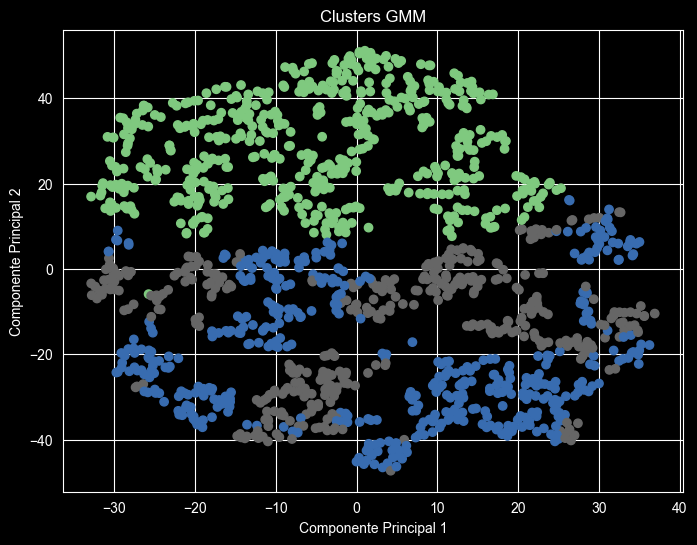

In [55]:
gmm = GaussianMixture(
    n_components=3,
    random_state=42
)

clusters_gmm = gmm.fit_predict(X_cluster_scaled)

plt.figure(figsize=(8,6))

plt.scatter(
    X_tsne[:,0],
    X_tsne[:,1],
    c=clusters_gmm,
    cmap='Accent'
)

plt.title('Clusters GMM')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')

plt.show()

<h2>4. Classificação</h2>

O principal objetivo deste projeto consiste em prever o nível de impacto ambiental dos indivíduos com base em seus hábitos de consumo e sustentabilidade. Para isso, foram utilizados algoritmos de aprendizado supervisionado capazes de aprender padrões presentes nos dados históricos e classificar novos usuários nas categorias Low Impact, Medium Impact ou High Impact.

In [26]:
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, classification_report

#Seleção das características numéricas preditoras e do alvo categórico
fatores_preditores = ['electricity_kwh', 'waste_generated_kg', 'renewable_usage_pct', 'distance_km']
X = df[fatores_preditores]
y = df['carbon_impact_level']

#Normalização por escala
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#Divisão Holdout: 70% Treinamento e 30% Teste
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.30, random_state=42)

#Configuração para Validação Cruzada (k=10)
cv_estrategia = KFold(n_splits=10, shuffle=True, random_state=42)

In [28]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_smote, y_smote = smote.fit_resample(
    X_scaled,
    y
)

print(pd.Series(y_smote).value_counts())

carbon_impact_level
Low       869
Medium    869
High      869
Name: count, dtype: int64


In [29]:
from imblearn.under_sampling import RandomUnderSampler

rus = RandomUnderSampler(random_state=42)

X_under, y_under = rus.fit_resample(
    X_scaled,
    y
)

print(pd.Series(y_under).value_counts())

carbon_impact_level
High      194
Low       194
Medium    194
Name: count, dtype: int64


<h3>4.2. Árvore de Decisão</h3>
A Árvore de Decisão é um algoritmo supervisionado que realiza classificações por meio de uma estrutura hierárquica composta por nós de decisão e folhas. Em cada etapa, o algoritmo seleciona o atributo que melhor separa os dados, construindo regras interpretáveis que auxiliam na compreensão do processo de classificação.

,Método,Acurácia,F1 Macro
0,Original,0.6976,0.5992
1,SMOTE,0.7535,0.7469
2,UnderSampling,0.7143,0.6977


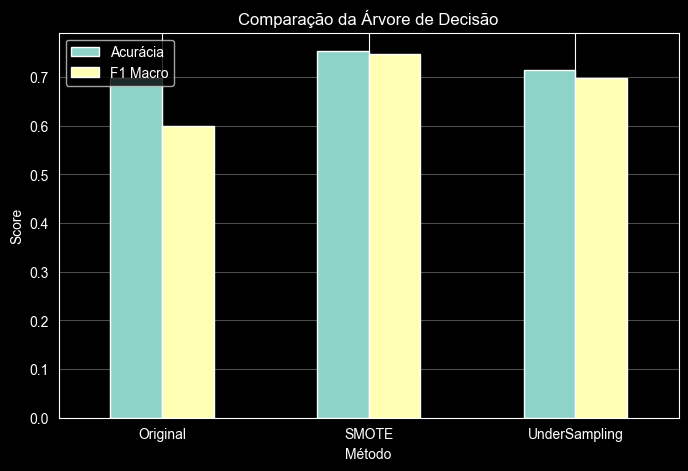

In [30]:
fatores_preditores = ['electricity_kwh', 'waste_generated_kg', 'renewable_usage_pct', 'distance_km']
X = df[fatores_preditores]
y = df['carbon_impact_level']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#Divisão Holdout
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.30, random_state=42
)

arvore_original = DecisionTreeClassifier(max_depth=4, random_state=42)
arvore_original.fit(X_train, y_train)

#Predição
y_pred_arvore_original = arvore_original.predict(X_test)

#Exibição das métricas
acc_arvore_original = accuracy_score(y_test, y_pred_arvore_original)
f1_original = f1_score(y_test, y_pred_arvore_original, average='macro')

#SMOTE

X_train_sm, X_test_sm, y_train_sm, y_test_sm = train_test_split(
    X_smote,
    y_smote,
    test_size=0.30,
    random_state=42
)

arvore_smote = DecisionTreeClassifier(
    max_depth=4,
    random_state=42
)

arvore_smote.fit(X_train_sm, y_train_sm)

pred_smote = arvore_smote.predict(X_test_sm)

acc_smote = accuracy_score(y_test_sm, pred_smote)
f1_smote = f1_score(y_test_sm, pred_smote, average='macro')

#UNDERSAMPLING

X_train_us, X_test_us, y_train_us, y_test_us = train_test_split(
    X_under,
    y_under,
    test_size=0.30,
    random_state=42
)

arvore_under = DecisionTreeClassifier(
    max_depth=4,
    random_state=42
)

arvore_under.fit(X_train_us, y_train_us)

pred_under = arvore_under.predict(X_test_us)

acc_under = accuracy_score(y_test_us, pred_under)
f1_under = f1_score(y_test_us, pred_under, average='macro')

#COMPARAÇÃO

comparacao = pd.DataFrame({
    'Método': ['Original', 'SMOTE', 'UnderSampling'],
    'Acurácia': [acc_arvore_original, acc_smote, acc_under],
    'F1 Macro': [f1_original, f1_smote, f1_under]
})

display(comparacao.round(4))

comparacao.set_index('Método').plot(
    kind='bar',
    figsize=(8,5)
)

plt.title('Comparação da Árvore de Decisão')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)

plt.show()

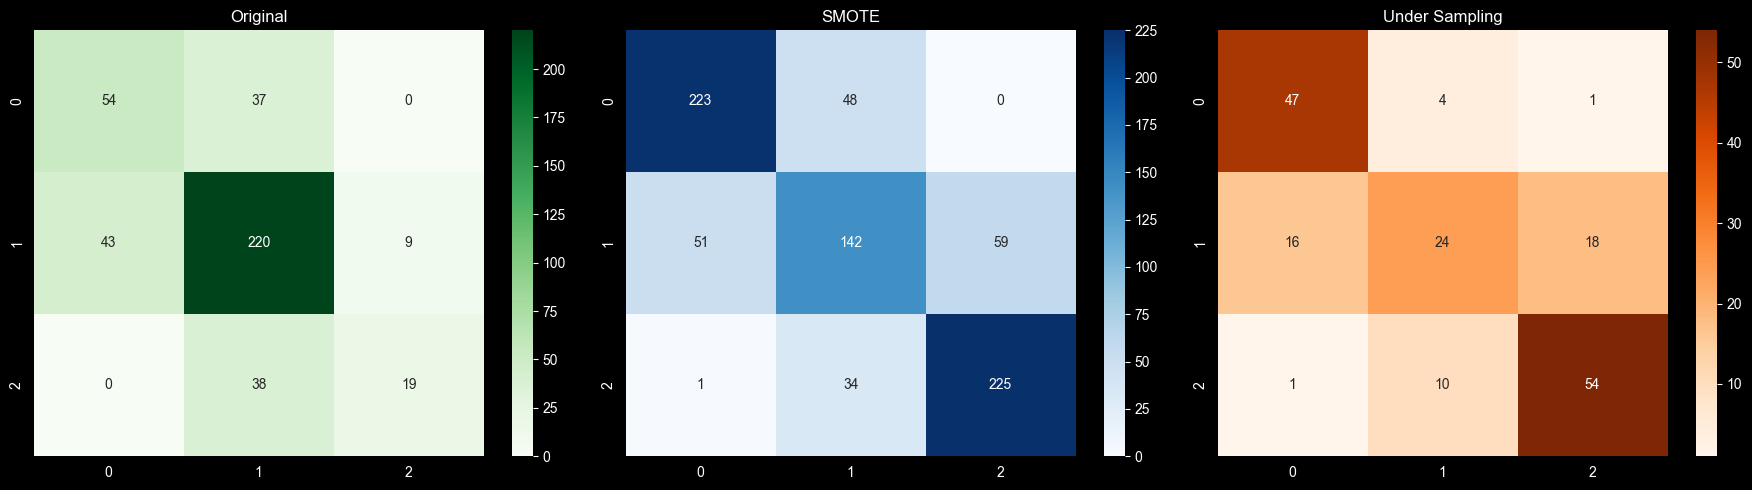

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(18,5))

classes_ordem = ['Low', 'Medium', 'High']

# Original
sns.heatmap(
    confusion_matrix(y_test, y_pred_arvore_original, labels=classes_ordem),
    annot=True,
    fmt='d',
    cmap='Greens',
    ax=axes[0]
)
axes[0].set_title('Original')

# SMOTE
sns.heatmap(
    confusion_matrix(y_test_sm, pred_smote, labels=classes_ordem),
    annot=True,
    fmt='d',
    cmap='Blues',
    ax=axes[1]
)
axes[1].set_title('SMOTE')

# UnderSampling
sns.heatmap(
    confusion_matrix(y_test_us, pred_under, labels=classes_ordem),
    annot=True,
    fmt='d',
    cmap='Oranges',
    ax=axes[2]
)
axes[2].set_title('Under Sampling')

plt.tight_layout()
plt.show()

,Variável,Original,SMOTE,UnderSampling
0,electricity_kwh,0.3419,0.4214,0.4261
1,waste_generated_kg,0.0727,0.0338,0.0564
2,renewable_usage_pct,0.5753,0.5448,0.4814
3,distance_km,0.0101,0.0000,0.0361


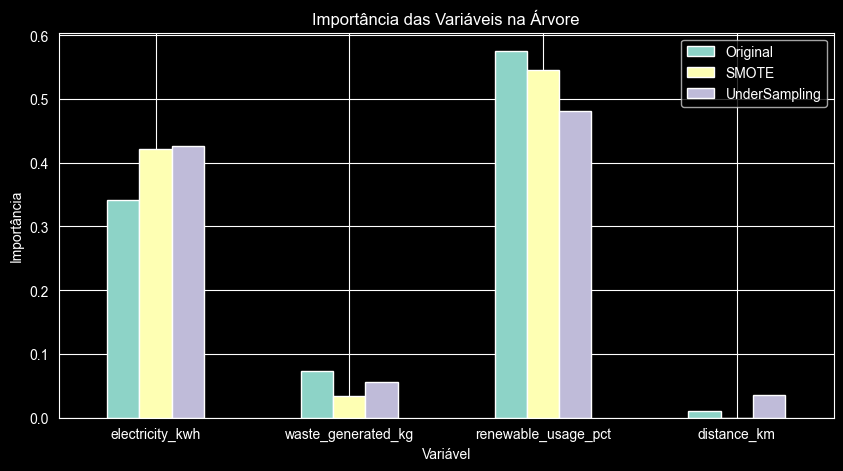

In [32]:
importancias = pd.DataFrame({
    'Variável': fatores_preditores,
    'Original': arvore_original.feature_importances_,
    'SMOTE': arvore_smote.feature_importances_,
    'UnderSampling': arvore_under.feature_importances_
})

display(importancias.round(4))

importancias.set_index('Variável').plot(
    kind='bar',
    figsize=(10,5)
)

plt.title('Importância das Variáveis na Árvore')
plt.ylabel('Importância')
plt.xticks(rotation=0)

plt.show()

<h3>4.3. KNN (K-Nearest Neighbors)</h3>
O algoritmo KNN foi aplicado considerando que indivíduos com hábitos semelhantes tendem a apresentar níveis de impacto ambiental parecidos. Dessa forma, a classificação de um novo usuário é realizada com base na proximidade em relação aos perfis já conhecidos na base de dados.

In [33]:
modelo_knn_original = KNeighborsClassifier(n_neighbors=7)

modelo_knn_original.fit(X_train, y_train)

pred_original = modelo_knn_original.predict(X_test)

acc_original = accuracy_score(y_test, pred_original)
f1_original = f1_score(y_test, pred_original, average='macro')

scores_cv_original = cross_val_score(
    modelo_knn_original,
    X_scaled,
    y,
    cv=cv_estrategia,
    scoring='accuracy'
)

# ======================================
# KNN - SMOTE
# ======================================

modelo_knn_smote = KNeighborsClassifier(n_neighbors=7)

modelo_knn_smote.fit(X_train_sm, y_train_sm)

pred_smote = modelo_knn_smote.predict(X_test_sm)

acc_smote = accuracy_score(y_test_sm, pred_smote)
f1_smote = f1_score(y_test_sm, pred_smote, average='macro')

scores_cv_smote = cross_val_score(
    modelo_knn_smote,
    X_smote,
    y_smote,
    cv=cv_estrategia,
    scoring='accuracy'
)

# ======================================
# KNN - UNDER SAMPLING
# ======================================

modelo_knn_under = KNeighborsClassifier(n_neighbors=7)

modelo_knn_under.fit(X_train_us, y_train_us)

pred_under = modelo_knn_under.predict(X_test_us)

acc_under = accuracy_score(y_test_us, pred_under)
f1_under = f1_score(y_test_us, pred_under, average='macro')

scores_cv_under = cross_val_score(
    modelo_knn_under,
    X_under,
    y_under,
    cv=cv_estrategia,
    scoring='accuracy'
)

,Método,Acurácia Holdout,F1 Macro,CV 10-Fold
0,Original,0.7190,0.6515,0.680
1,SMOTE,0.7727,0.7525,0.781
2,UnderSampling,0.7314,0.7273,0.706


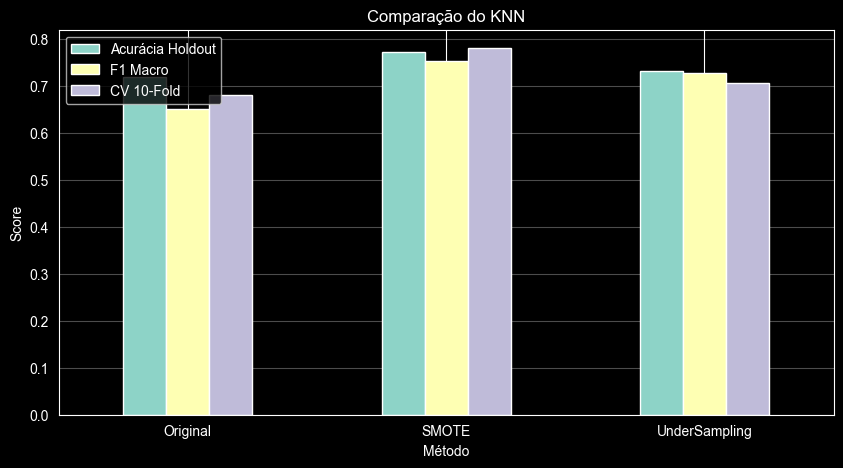

In [34]:
comparacao_knn = pd.DataFrame({
    'Método': ['Original', 'SMOTE', 'UnderSampling'],
    'Acurácia Holdout': [
        acc_original,
        acc_smote,
        acc_under
    ],
    'F1 Macro': [
        f1_original,
        f1_smote,
        f1_under
    ],
    'CV 10-Fold': [
        scores_cv_original.mean(),
        scores_cv_smote.mean(),
        scores_cv_under.mean()
    ]
})

display(comparacao_knn.round(4))

comparacao_knn.set_index('Método').plot(
    kind='bar',
    figsize=(10,5)
)

plt.title('Comparação do KNN')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)

plt.show()

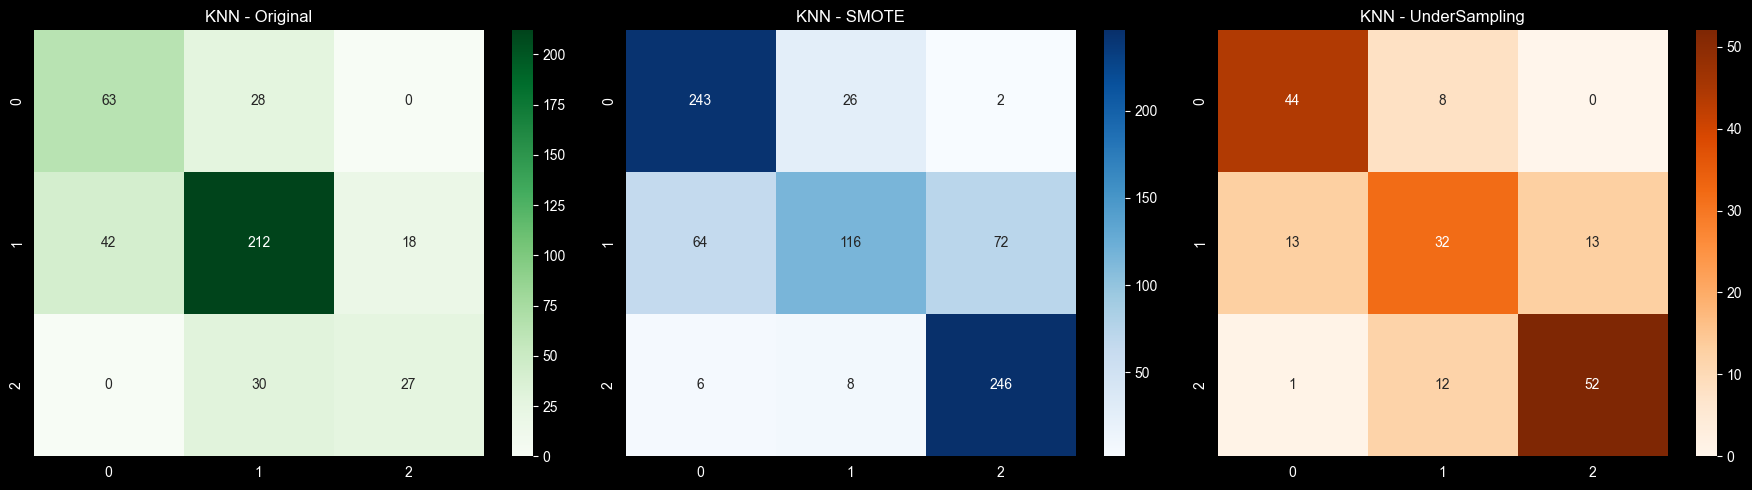

In [35]:
fig, axes = plt.subplots(1, 3, figsize=(18,5))

classes = ['Low', 'Medium', 'High']

# Original
sns.heatmap(
    confusion_matrix(y_test, pred_original, labels=classes),
    annot=True,
    fmt='d',
    cmap='Greens',
    ax=axes[0]
)
axes[0].set_title('KNN - Original')

# SMOTE
sns.heatmap(
    confusion_matrix(y_test_sm, pred_smote, labels=classes),
    annot=True,
    fmt='d',
    cmap='Blues',
    ax=axes[1]
)
axes[1].set_title('KNN - SMOTE')

# UnderSampling
sns.heatmap(
    confusion_matrix(y_test_us, pred_under, labels=classes),
    annot=True,
    fmt='d',
    cmap='Oranges',
    ax=axes[2]
)
axes[2].set_title('KNN - UnderSampling')

plt.tight_layout()
plt.show()

In [36]:
print("========== KNN ORIGINAL ==========")
print(classification_report(y_test, pred_original))

print("\n========== KNN SMOTE ==========")
print(classification_report(y_test_sm, pred_smote))

print("\n========== KNN UNDERSAMPLING ==========")
print(classification_report(y_test_us, pred_under))

========== KNN ORIGINAL ==========
              precision    recall  f1-score   support

        High       0.60      0.47      0.53        57
         Low       0.60      0.69      0.64        91
      Medium       0.79      0.78      0.78       272

    accuracy                           0.72       420
   macro avg       0.66      0.65      0.65       420
weighted avg       0.72      0.72      0.72       420


========== KNN SMOTE ==========
              precision    recall  f1-score   support

        High       0.77      0.95      0.85       260
         Low       0.78      0.90      0.83       271
      Medium       0.77      0.46      0.58       252

    accuracy                           0.77       783
   macro avg       0.77      0.77      0.75       783
weighted avg       0.77      0.77      0.76       783


========== KNN UNDERSAMPLING ==========
              precision    recall  f1-score   support

        High       0.80      0.80      0.80        65
         Low       0

<h3>4.4. SVM (Support Vector Machine)</h3>
O SVM foi utilizado para identificar fronteiras de separação entre os diferentes níveis de impacto ambiental. Como a classificação depende da interação de diversos fatores simultaneamente, esse algoritmo é capaz de encontrar regiões do espaço de atributos que melhor distinguem indivíduos de baixo, médio e alto impacto.

In [37]:
#Instanciando o SVM
modelo_svm_original = SVC(
    kernel='rbf',
    C=1.0,
    random_state=42
)

modelo_svm_original.fit(X_train, y_train)

pred_original = modelo_svm_original.predict(X_test)

acc_original = accuracy_score(y_test, pred_original)
f1_original = f1_score(y_test, pred_original, average='macro')

scores_cv_original = cross_val_score(
    modelo_svm_original,
    X_scaled,
    y,
    cv=cv_estrategia,
    scoring='accuracy'
)

# ======================================
# SVM - SMOTE
# ======================================

modelo_svm_smote = SVC(
    kernel='rbf',
    C=1.0,
    random_state=42
)

modelo_svm_smote.fit(X_train_sm, y_train_sm)

pred_smote = modelo_svm_smote.predict(X_test_sm)

acc_smote = accuracy_score(y_test_sm, pred_smote)
f1_smote = f1_score(y_test_sm, pred_smote, average='macro')

scores_cv_smote = cross_val_score(
    modelo_svm_smote,
    X_smote,
    y_smote,
    cv=cv_estrategia,
    scoring='accuracy'
)

# ======================================
# SVM - UNDER SAMPLING
# ======================================

modelo_svm_under = SVC(
    kernel='rbf',
    C=1.0,
    random_state=42
)

modelo_svm_under.fit(X_train_us, y_train_us)

pred_under = modelo_svm_under.predict(X_test_us)

acc_under = accuracy_score(y_test_us, pred_under)
f1_under = f1_score(y_test_us, pred_under, average='macro')

scores_cv_under = cross_val_score(
    modelo_svm_under,
    X_under,
    y_under,
    cv=cv_estrategia,
    scoring='accuracy'
)

,Método,Acurácia Holdout,F1 Macro,CV 10-Fold
0,Original,0.7119,0.6281,0.7121
1,SMOTE,0.7586,0.7467,0.7633
2,UnderSampling,0.7200,0.7134,0.7198


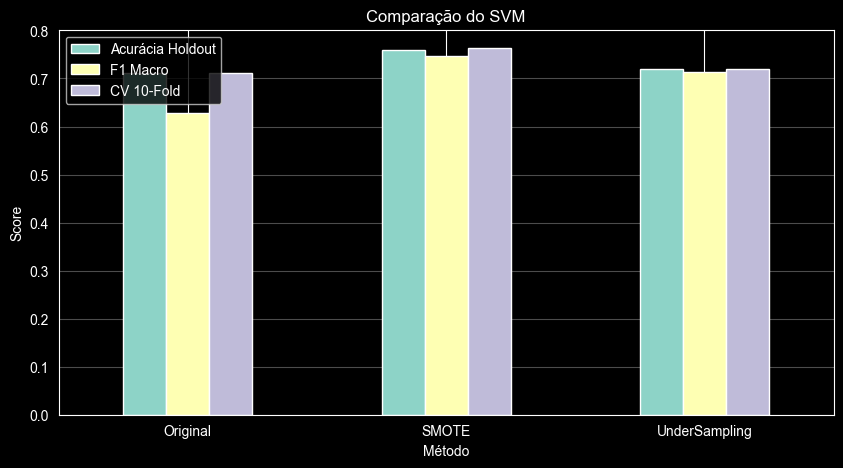

In [38]:
comparacao_svm = pd.DataFrame({
    'Método': ['Original', 'SMOTE', 'UnderSampling'],
    'Acurácia Holdout': [
        acc_original,
        acc_smote,
        acc_under
    ],
    'F1 Macro': [
        f1_original,
        f1_smote,
        f1_under
    ],
    'CV 10-Fold': [
        scores_cv_original.mean(),
        scores_cv_smote.mean(),
        scores_cv_under.mean()
    ]
})

display(comparacao_svm.round(4))

comparacao_svm.set_index('Método').plot(
    kind='bar',
    figsize=(10,5)
)

plt.title('Comparação do SVM')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)

plt.show()

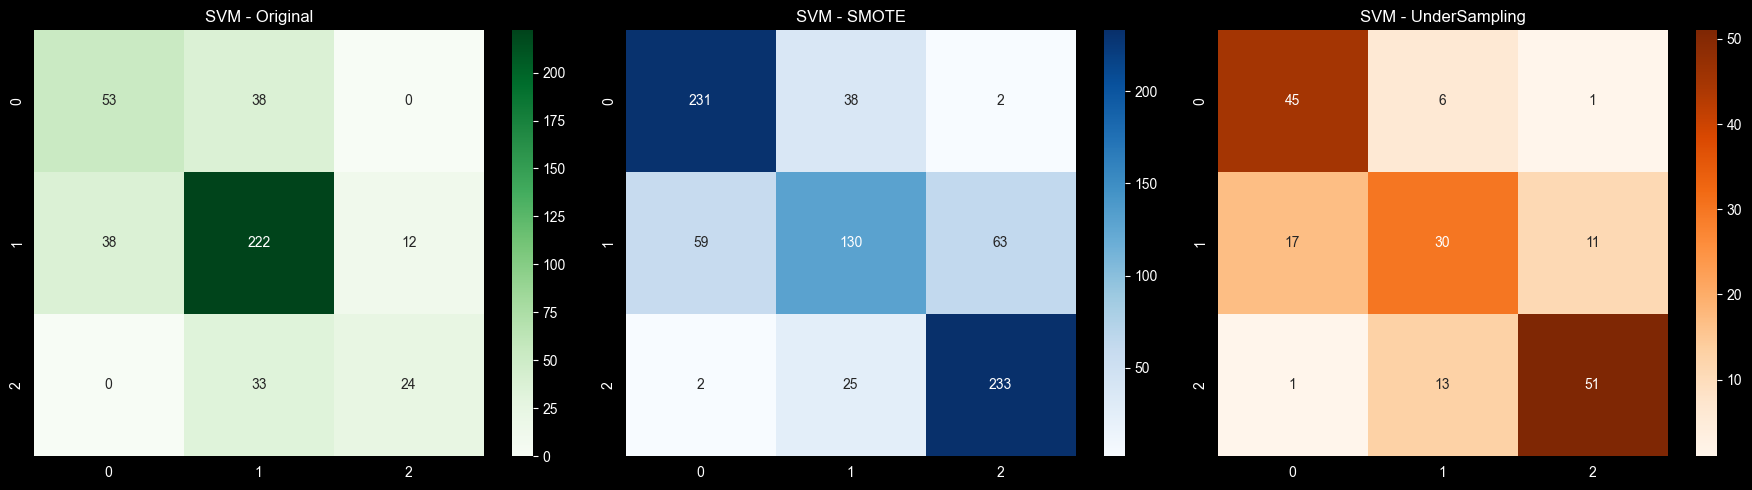

In [39]:
fig, axes = plt.subplots(1, 3, figsize=(18,5))

classes = ['Low', 'Medium', 'High']

# Original
sns.heatmap(
    confusion_matrix(y_test, pred_original, labels=classes),
    annot=True,
    fmt='d',
    cmap='Greens',
    ax=axes[0]
)
axes[0].set_title('SVM - Original')

# SMOTE
sns.heatmap(
    confusion_matrix(y_test_sm, pred_smote, labels=classes),
    annot=True,
    fmt='d',
    cmap='Blues',
    ax=axes[1]
)
axes[1].set_title('SVM - SMOTE')

# UnderSampling
sns.heatmap(
    confusion_matrix(y_test_us, pred_under, labels=classes),
    annot=True,
    fmt='d',
    cmap='Oranges',
    ax=axes[2]
)
axes[2].set_title('SVM - UnderSampling')

plt.tight_layout()
plt.show()

In [40]:
print("========== SVM ORIGINAL ==========")
print(classification_report(y_test, pred_original))

print("\n========== SVM SMOTE ==========")
print(classification_report(y_test_sm, pred_smote))

print("\n========== SVM UNDERSAMPLING ==========")
print(classification_report(y_test_us, pred_under))

========== SVM ORIGINAL ==========
              precision    recall  f1-score   support

        High       0.67      0.42      0.52        57
         Low       0.58      0.58      0.58        91
      Medium       0.76      0.82      0.79       272

    accuracy                           0.71       420
   macro avg       0.67      0.61      0.63       420
weighted avg       0.71      0.71      0.71       420


========== SVM SMOTE ==========
              precision    recall  f1-score   support

        High       0.78      0.90      0.84       260
         Low       0.79      0.85      0.82       271
      Medium       0.67      0.52      0.58       252

    accuracy                           0.76       783
   macro avg       0.75      0.75      0.75       783
weighted avg       0.75      0.76      0.75       783


========== SVM UNDERSAMPLING ==========
              precision    recall  f1-score   support

        High       0.81      0.78      0.80        65
         Low       0

<h3>4.5. Rede Neural Artificial</h3>
<h4>MLP</h4>
A rede neural MLP foi empregada para capturar relações complexas e não lineares entre os atributos da base. Diferentemente de modelos mais simples, ela possui capacidade de aprender interações entre consumo energético, geração de resíduos, uso de energia renovável e outros fatores que influenciam a pegada de carbono. O objetivo é verificar se essa maior capacidade de modelagem resulta em um desempenho superior na classificação dos níveis de impacto ambiental.

In [50]:
from sklearn.neural_network import MLPClassifier

mlp_original = MLPClassifier(
    hidden_layer_sizes=(16, 8),
    activation='relu',
    solver='adam',
    max_iter=5000,           # ← Aumentado para garantir convergência
    learning_rate_init=0.001, # ← Taxa de aprendizado explícita
    validation_fraction=0.1,  # ← 10% dos dados para validação interna
    n_iter_no_change=20,      # ← Para se não melhorar por 20 épocas
    random_state=42
)

mlp_original.fit(X_train, y_train)

pred_original = mlp_original.predict(X_test)

acc_original = accuracy_score(y_test, pred_original)
f1_original = f1_score(y_test, pred_original, average='macro')

scores_cv_original = cross_val_score(
    mlp_original,
    X_scaled,
    y,
    cv=cv_estrategia,
    scoring='accuracy'
)

# ======================================
# MLP - SMOTE
# ======================================

mlp_smote = MLPClassifier(
    hidden_layer_sizes=(16, 8),
    activation='relu',
    solver='adam',
    max_iter=5000,           # ← Aumentado para garantir convergência
    learning_rate_init=0.001, # ← Taxa de aprendizado explícita
    validation_fraction=0.1,  # ← 10% dos dados para validação interna
    n_iter_no_change=20,      # ← Para se não melhorar por 20 épocas
    random_state=42
)

mlp_smote.fit(X_train_sm, y_train_sm)

pred_smote = mlp_smote.predict(X_test_sm)

acc_smote = accuracy_score(y_test_sm, pred_smote)
f1_smote = f1_score(y_test_sm, pred_smote, average='macro')

scores_cv_smote = cross_val_score(
    mlp_smote,
    X_smote,
    y_smote,
    cv=cv_estrategia,
    scoring='accuracy'
)

# ======================================
# MLP - UNDER SAMPLING
# ======================================

mlp_under = MLPClassifier(
    hidden_layer_sizes=(16, 8),
    activation='relu',
    solver='adam',
    max_iter=5000,           # ← Aumentado para garantir convergência
    learning_rate_init=0.001, # ← Taxa de aprendizado explícita
    validation_fraction=0.1,  # ← 10% dos dados para validação interna
    n_iter_no_change=20,      # ← Para se não melhorar por 20 épocas
    random_state=42
)

mlp_under.fit(X_train_us, y_train_us)

pred_under = mlp_under.predict(X_test_us)

acc_under = accuracy_score(y_test_us, pred_under)
f1_under = f1_score(y_test_us, pred_under, average='macro')

scores_cv_under = cross_val_score(
    mlp_under,
    X_under,
    y_under,
    cv=cv_estrategia,
    scoring='accuracy'
)

,Método,Acurácia Holdout,F1 Macro,CV 10-Fold
0,Original,0.7190,0.6639,0.6986
1,SMOTE,0.7548,0.7420,0.7729
2,UnderSampling,0.7371,0.7328,0.7249


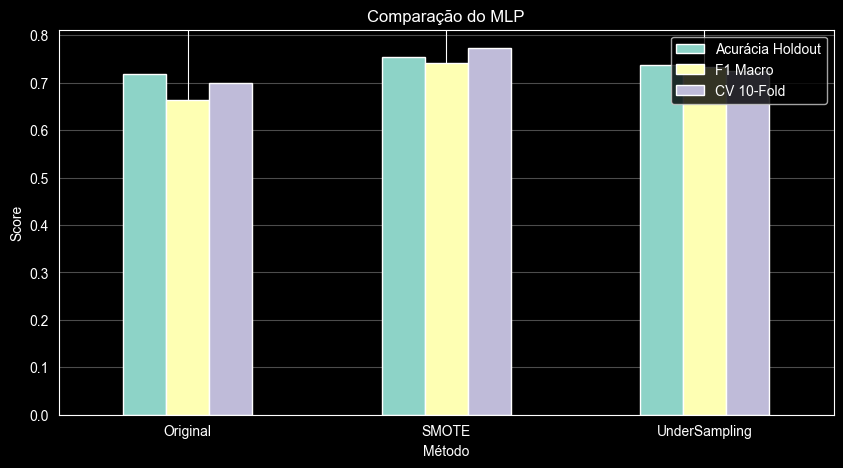

In [52]:
# Tabela comparativa
comparacao_mlp = pd.DataFrame({
    'Método': ['Original', 'SMOTE', 'UnderSampling'],
    'Acurácia Holdout': [
        acc_original,
        acc_smote,
        acc_under
    ],
    'F1 Macro': [
        f1_original,
        f1_smote,
        f1_under
    ],
    'CV 10-Fold': [
        scores_cv_original.mean(),
        scores_cv_smote.mean(),
        scores_cv_under.mean()
    ]
})

display(comparacao_mlp.round(4))

comparacao_mlp.set_index('Método').plot(
    kind='bar',
    figsize=(10, 5)
)

plt.title('Comparação do MLP')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.show()

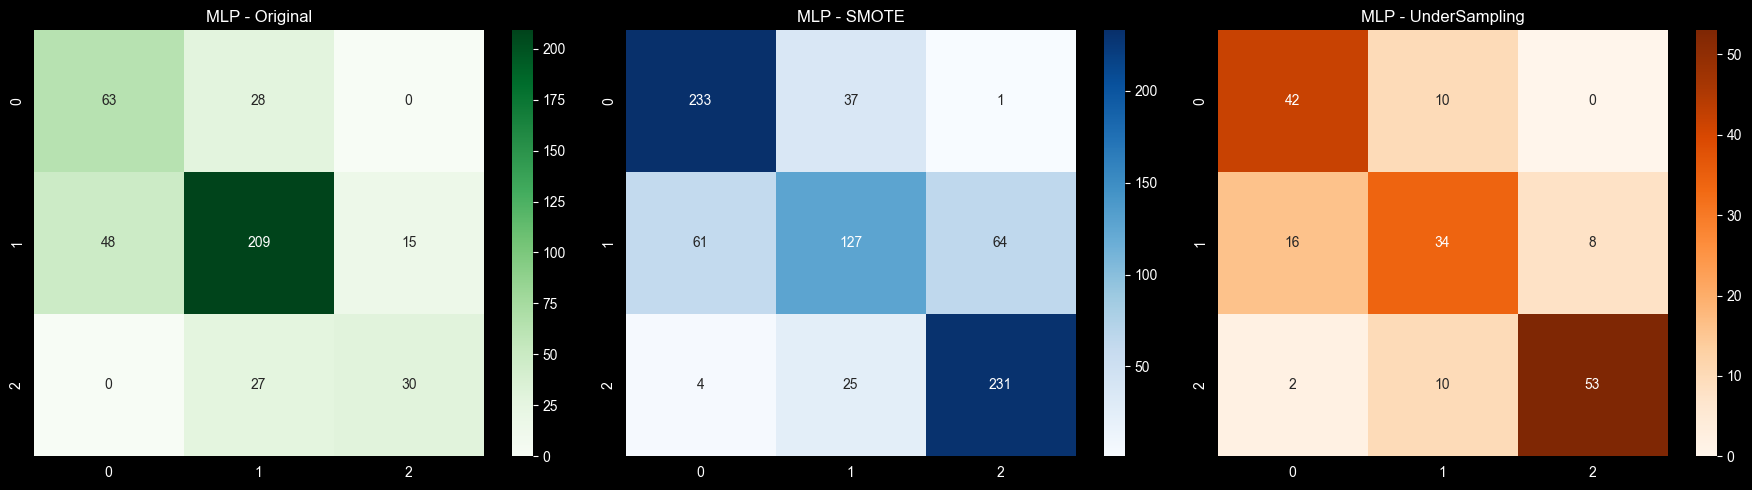

========== MLP ORIGINAL ==========
              precision    recall  f1-score   support

        High       0.67      0.53      0.59        57
         Low       0.57      0.69      0.62        91
      Medium       0.79      0.77      0.78       272

    accuracy                           0.72       420
   macro avg       0.68      0.66      0.66       420
weighted avg       0.73      0.72      0.72       420


========== MLP SMOTE ==========
              precision    recall  f1-score   support

        High       0.78      0.89      0.83       260
         Low       0.78      0.86      0.82       271
      Medium       0.67      0.50      0.58       252

    accuracy                           0.75       783
   macro avg       0.74      0.75      0.74       783
weighted avg       0.75      0.75      0.74       783


========== MLP UNDERSAMPLING ==========
              precision    recall  f1-score   support

        High       0.87      0.82      0.84        65
         Low       0

In [53]:
# Matrizes de confusão
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

classes = ['Low', 'Medium', 'High']

# Original
sns.heatmap(
    confusion_matrix(y_test, pred_original, labels=classes),
    annot=True,
    fmt='d',
    cmap='Greens',
    ax=axes[0]
)
axes[0].set_title('MLP - Original')

# SMOTE
sns.heatmap(
    confusion_matrix(y_test_sm, pred_smote, labels=classes),
    annot=True,
    fmt='d',
    cmap='Blues',
    ax=axes[1]
)
axes[1].set_title('MLP - SMOTE')

# UnderSampling
sns.heatmap(
    confusion_matrix(y_test_us, pred_under, labels=classes),
    annot=True,
    fmt='d',
    cmap='Oranges',
    ax=axes[2]
)
axes[2].set_title('MLP - UnderSampling')

plt.tight_layout()
plt.show()

# Relatórios de classificação
print("========== MLP ORIGINAL ==========")
print(classification_report(y_test, pred_original))

print("\n========== MLP SMOTE ==========")
print(classification_report(y_test_sm, pred_smote))

print("\n========== MLP UNDERSAMPLING ==========")
print(classification_report(y_test_us, pred_under))